# Comments

Goal:
- Create new "applications" dataset that includes the follower count at that point in time and the creator location (maybe reviews?)
    - Gives us information on the quality of the applications for each deal (do they have many followers and are they close?)


General comments
- Analyse the location data we have for applications for deals
    - E.g., for physical deals, can we get an estimate of the average distance of the creator to the deal? Does it matter? How can I tie this back to the model predicting apps? 
- Remove influencer_id = 20694, it is Hugo

To-do:
- Merge the deal data with the application data to one huge dataset. 

# Init

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

import numpy as np
import pandas as pd

from src.utils import interactive_dataframe_selector

In [2]:
# Load environment variables from .env file
load_dotenv("../private_data/.env")

host = os.getenv("HOST")
db = os.getenv("DB")
port = os.getenv("PORT")
role = os.getenv("ROLE")
pw = os.getenv("PASSWORD")
engine = create_engine(f"postgresql+psycopg2://{role}:{pw}@{host}:{port}/{db}")

# Create apps dataset
- We create an apps dataset that contains all the creator metadata, so we can include it when computing the deal-aggregate statistics 
    - E.g., per deal:
        - Mean follower count
        - Distance to deal
        - Mean age (sparse but possible)
        - Nr. of active users in the month/week before the deal went live
- Merge following datasets:
    - Applications 
    - Company locations
    - deal details 
    - Applicant (influencer) details

## Applications

Clean df_apps:
- Only valid applications:
    - Correct region
    - Meets follower requirement
    - Unique application
    - Not a Barter deal: all non-barter emails are anonymized, filter where email contains anonymized

In [3]:
query = 'SELECT * FROM public.deal_applications;'
df_apps = pd.read_sql(query, engine)
# # Filter some creators that we know are dev team
# creators_to_filter = [20694, 42852]
# df_apps = df_apps[~df_apps['creator_id'].isin(creators_to_filter)]
df_apps.rename(columns={'status': 'application_status',
               'created_at': "application_created_at"}, inplace=True)

df_apps['legacy_location_id'] = df_apps['legacy_location_id'].astype('Int64')
df_apps.drop(columns='id', inplace=True)

OperationalError: (psycopg2.OperationalError) could not translate host name "rds-proxy.development.getbarter.tech" to address: No such host is known. 

(Background on this error at: https://sqlalche.me/e/20/e3q8)

## Company locations

In [ ]:
cols_locations = ['created_at', 'updated_at', 'deleted_at', 'id', 'company_id', 'partner_id', 'migrated_from_location_id',
                  'name',  'address', 'postal_code', 'country', 'latitude', 'longitude', 'country_code', 'town_slug']

query_locations = f"SELECT {', '.join(cols_locations)} FROM public.company_locations;"

# query = 'SELECT * FROM public.company_locations;'
df_locations = pd.read_sql(query_locations, engine)
df_locations = df_locations[df_locations['address'] != ""]


def extract_city(row):
    address = str(row['address'])
    postcode = str(row['postal_code'])

    # Split the address by comma
    parts = address.split(',')

    # Find the segment that contains the postcode
    for part in parts:
        if postcode in part:
            # Remove the postcode from that segment and strip whitespace
            clean_city = part.replace(postcode, '').strip()
            return clean_city

    if len(parts) > 1:
        parts2 = parts[-2].split(" ")
        return parts2[-1]
        # if len(parts2) == 1:
        #     return parts2
        # else:
        #     return parts2[-1]

    else:
        return parts[0]


# Apply only to the masked rows
df_locations.loc[:, 'city'] = df_locations.apply(extract_city, axis=1)
df_locations = df_locations.add_suffix('_partner')

## Influencers/ creators

In [4]:
# 1. Wrap the entire row in a JSON blob using the database's native function
# 'row_to_json' works for PostgreSQL. For MySQL use 'JSON_OBJECT'.
query = "SELECT row_to_json(t) as data_blob FROM public.influencers_table_view t;"

# 2. Read the JSON blobs (Pandas receives them as a column of dictionaries)
df_wrapper = pd.read_sql(query, engine)

# 3. Expand the dictionaries back into a proper DataFrame
df_creators = pd.json_normalize(df_wrapper['data_blob'])

# Now you have your full dataframe, and dates are just Strings.
# You can clean them safely without crashing.
df_creators['birthday'] = pd.to_datetime(
    df_creators['birthday'], errors='coerce')
df_creators['created_at'] = pd.to_datetime(
    df_creators['created_at'], errors='coerce')

df_creators.rename(columns={'status': 'status_creator',
                            "created_at": "created_at_creator",
                            "longitude": "longitude_creator",
                            "latitude": "latitude_creator",
                            "email_address": "email_address_creator"}, inplace=True)
# df_creators = df_creators.add_suffix('_creator')

df_creators.drop(columns=['url'], inplace=True)

# Standardize country names
df_creators.loc[df_creators.country == 'Nederland', 'country'] = "Netherlands"
df_creators.loc[df_creators.country == 'Belgique', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'België', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'UK', 'country'] = "United Kingdom"
df_creators.loc[df_creators.country == 'Deutschland', 'country'] = "Germany"

OperationalError: (psycopg2.OperationalError) could not translate host name "rds-proxy.development.getbarter.tech" to address: No such host is known. 

(Background on this error at: https://sqlalche.me/e/20/e3q8)

## Partners

Comments:
- I can optionally link the online deals with the partner locations, but that will be one to many (e.g., some online deals are actually physical, like the Michael Jackson tribute deal, with location Ahoy- but this is not uniquely linked to a deal; the partner_id is linked to all the partner's locations, and the deal is not specifically linked to Ahoy)

In [99]:
query = 'SELECT * FROM public.partners_table_view;'
df_partners = pd.read_sql(query, engine)
df_partners = df_partners.rename(columns={'vendor_id': 'partner_id'})

df_partners = df_partners.loc[:,['partner_id', 'company_name', 'country', 'website', 'email_address', 'registered_at', 'subscription_status', 'subscription_start_date', 'subscription_end_date', 'deals_count', 'live_deals_count', 'locations_count', 'company_size', 'worked_with_creators']]

# mask = df_partners['email_address'].str.contains('anonymized') # Other ones are dev team
# df_partners_invalid = df_partners[~mask]
# df_partners = df_partners[mask]

# df_apps.rename(columns={'status': 'application_status', 'created_at': "application_created_at"}, inplace=True)

## Deals

In [100]:
# Define your column lists
cols_deals = ['created_at', 'updated_at', 'deleted_at', 'id', 'legacy_partner_id', 'title', 'description', 'creators_requirement', 'hash_tags', 'status', 'deal_value', 'go_live_at', 'live_until', 'deal_type',
              'images', 'accepts_international', 'accepted_countries', 'social_requirement_type_id', 'product_name', 'schedule_type', 'schedule_model', 'legacy_id', 'tags', 'gender', 'featured_image', 'company_id', 'partner_id']
cols_comp = ['applicants_applications_count', 'cancelled_applications_count', 'company_locations', 'completed_applications_count', 'content_types', 'deal_created_at', 'deal_deleted_at', 'deal_id', 'deal_tags', 'deal_updated_at',
             'first_application_at', 'last_application_at', 'live_since', 'main_image', 'min_social_media_followers', 'pending_applications_count', 'planned_applications_count', 'rejected_applications_count', 'total_company_locations']

# 1. Load Deals
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

# 2. Load Deals Computed with built-in date parsing
# We add deal_id::text as deal_id_str directly in the SQL string
# query_comp = f"""
#     SELECT {', '.join(cols_comp)}, deal_id::text AS deal_id_str 
#     FROM public.deals_computed;
# """

query_comp = f"""
    SELECT {', '.join(cols_comp)}
    FROM public.deals_computed;
"""

df_deals_comp = pd.read_sql(
    query_comp,
    engine,
    parse_dates=['first_application_at', 'last_application_at']
)

# Merge
df_deals = pd.merge(df_deals,
                    df_deals_comp,
                    left_on='id', right_on='deal_id')

del df_deals_comp
# Text takes up a lot of memory, can drop since it is not needed
df_deals.drop(columns=['description', 'creators_requirement', 'schedule_model', 'main_image', 'images', 'id'], inplace=True)
df_deals.rename(columns={'status': 'status_deals'}, inplace=True)

## Company locations

In [101]:
cols_locations = ['created_at', 'updated_at', 'deleted_at', 'id', 'company_id', 'partner_id', 'migrated_from_location_id',
                  'name',  'address', 'postal_code', 'country', 'latitude', 'longitude', 'country_code', 'town_slug']

query_locations = f"SELECT {', '.join(cols_locations)} FROM public.company_locations;"

# query = 'SELECT * FROM public.company_locations;'
df_locations = pd.read_sql(query_locations, engine)
df_locations = df_locations[df_locations['address'] != ""]


def extract_city(row):
    address = str(row['address'])
    postcode = str(row['postal_code'])

    # Split the address by comma
    parts = address.split(',')

    # Find the segment that contains the postcode
    for part in parts:
        if postcode in part:
            # Remove the postcode from that segment and strip whitespace
            clean_city = part.replace(postcode, '').strip()
            return clean_city

    if len(parts) > 1:
        parts2 = parts[-2].split(" ")
        return parts2[-1]
        # if len(parts2) == 1:
        #     return parts2
        # else:
        #     return parts2[-1]

    else:
        return parts[0]


# Apply only to the masked rows
df_locations.loc[:, 'city'] = df_locations.apply(extract_city, axis=1)
df_locations = df_locations.add_suffix('_partner')

# Recover missing company_location_ids

In [102]:
print(f"Nr of unique locations: {len(df_apps.company_location_id.unique())}")


# deal_company_locations (122 unique)
## Merge deal_id with corresponding company_location_id
query = 'SELECT * FROM public.deal_company_locations;'
df_complocs = pd.read_sql(query, engine)

# 1. Turn your 57 rows into a fast lookup dictionary: { deal_id : company_location_id }
# Dropping duplicates just in case a deal_id appears twice in df_complocs
loc_map = df_complocs.drop_duplicates(subset=['deal_id'])\
                     .set_index('deal_id')['company_location_id']\
                     .to_dict()

# Find the exact rows in df_apps where the location is missing
mask_missing = df_apps['company_location_id'].isna()

# Use the map to fill ONLY the missing rows based on their deal_id
df_apps.loc[mask_missing, 'company_location_id'] = df_apps.loc[mask_missing, 'deal_id'].map(loc_map)
del df_complocs

print(f"Nr of unique locations: {len(df_apps.company_location_id.unique())}")

# company_locations
## Merge legacy_location_id with company_location_id (contains more legacy IDs than deal_company_locations)

# Create a dictionary: { 1205 : 'a1b2-c3d4', ... }
# Drop NaNs to keep the dictionary clean
df_locations['migrated_from_location_id_partner'] = df_locations['migrated_from_location_id_partner'].astype(
    'Int64')
legacy_to_modern_map = df_locations.dropna(subset=['migrated_from_location_id_partner'])\
    .set_index('migrated_from_location_id_partner')['id_partner']\
    .to_dict()

# 1. Find rows where Modern ID is missing but Legacy ID exists
mask_missing = (
    df_apps['company_location_id'].isna() &
    df_apps['legacy_location_id'].notna()
)

# Translate Legacy -> Modern for those specific rows
# We use .map() which is very fast
df_apps.loc[mask_missing, 'company_location_id'] = df_apps.loc[mask_missing,
                             'legacy_location_id'].map(legacy_to_modern_map)

print(f"Nr of unique locations: {len(df_apps.company_location_id.unique())}")



Nr of unique locations: 1699
Nr of unique locations: 1721
Nr of unique locations: 1806


# Merge

df_apps, df_creators, df_deals, df_locations, df_partners (?)

Problem with the merge: df_location and df_apps do not merge on company_location_id; there are still rows for which there is a location (we know because it is in df_deals), but the company_location_id is not in df_apps so it does not merge from df_location. 

Solution: we also have another id, legacy_location_id (migrated_from_location_id_partner). However, these IDs is also incomplete. Together, the legacy IDs and the company_location_ids should cover all rows in df_apps for the physical deals. The mapping between legacy IDs and company_location_ids is contained in df_location. Therefore, we check where df_apps['company_location_id'].isna() & df_apps['legacy_location_id'].notna() and fill in the legacy_location_id with the mapping. 

- Merge company_location_ids from other sources to fill in the missing ids

In [103]:
# To speed up the merge, subset df_locations with rows that are actually in df_apps
ids_to_find = df_apps['company_location_id'].dropna().unique()

# Filter locations to ONLY those IDs
df_locations_subset = df_locations[
    df_locations['id_partner'].isin(ids_to_find)
]


creator_cols = ['influencer_id', 'user_id', 'name', 'email_address_creator', 'phone_number',
                'country_code', 'gender', 'birthday', 'created_at_creator',
                'status_creator', 'socials', 'country', 'formatted_address',
                'address_name', 'latitude_creator', 'longitude_creator', 'place_id', 'state_machine']


df_apps_fin = df_apps.copy()
df_apps_fin = pd.merge(df_apps_fin, df_locations_subset, left_on='company_location_id',
                       right_on='id_partner', how='left', suffixes=('_apps', '_loc'))
df_apps_fin = pd.merge(df_apps_fin, df_deals, left_on='deal_id',
                       right_on='deal_id', how='left', suffixes=('', '_deals'))
df_apps_fin = pd.merge(df_apps_fin, df_creators[creator_cols], left_on='creator_id',
                       right_on='influencer_id', how='left', suffixes=('', '_creator'))
# df_apps_fin = pd.merge(df_apps_fin, df_partners, left_on='partner_id', right_on='partner_id', how='left',  suffixes=('', '_partners'))

In [104]:
df_apps_fin.memory_usage(deep=True) / 1e6

Index                  0.000132
legacy_partner_id      2.157872
legacy_location_id     2.427606
deal_id               19.420848
creator_id             2.157872
                        ...    
address_name          14.967427
latitude_creator       2.157872
longitude_creator      2.157872
place_id              19.632232
state_machine          2.157872
Length: 92, dtype: float64

In [120]:
sum(df_apps_fin.memory_usage(deep=True)) / 1e6

1064.035293

In [121]:
# 1. Grab the names of all 'object' columns
obj_cols = df_apps_fin.select_dtypes(include=['object']).columns

# 2. Convert them all to the native Pandas string type
df_apps_fin[obj_cols] = df_apps_fin[obj_cols].astype("string")

from src import paths
analysis_name = 'BARTER_DEAL_APPLICATIONS'
raw_data_path = paths.RAW_DATA_DIR / f'{analysis_name}.parquet'
df_apps_fin.to_parquet(raw_data_path)

--------

# Trying to solve the mystery of lost data when merging deals

To-do
- How does df_deals_comp have more locations than I can find with company locations?
- How serious is the problem; that is, how many deals do not have locations that should have them?
- Can I find whether online deals are actually physical?

Notes
- I have discovered that some deals without location do actually have a location (e.g., Try our sauna at Rotterdam Rijnhaven - FOR FREE); it shows in the backoffice. Where are they hiding in the database?
- When I check df_deals, all physical deals have locations. Should I just consider this as my ground truth? 
    - When I check which df_apps rows remain after subtracting the deals from df_deals, there are only around 50, most of them with company_location_id

In [19]:
import uuid


def set_subtract(series_A, series_B, col_A, col_B, return_len=True):
    setdiff = set(series_A[col_A]) - set(series_B[col_B])
    if return_len:
        return print(f"Original length: {len(set(series_A[col_A]))}\n New length: {len(setdiff)}")
    return setdiff


def get_orphans(series_A, series_B, col_A, col_B):
    # # 1. Get the unique set of existing deal IDs (faster lookup)
    existing_deal_ids = series_B[col_B].unique()

    # # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
    # # The tilde (~) means "NOT"
    mask_orphans = ~series_A[col_A].isin(existing_deal_ids)

    # # 3. Create the subset
    return series_A[mask_orphans]


def ulid_to_uuid(ulid_str):
    # Crockford's Base32 Alphabet
    _crockford = "0123456789ABCDEFGHJKMNPQRSTVWXYZ"
    # Create a mapping from char to value
    _map = {c: i for i, c in enumerate(_crockford)}

    # Normalize input
    s = ulid_str.upper().replace("-", "").replace("O",
                                                  "0").replace("I", "1").replace("L", "1")

    # Decode 26 characters (Base32) -> 128-bit integer
    val = 0
    for char in s:
        val = (val << 5) | _map[char]

    # Convert 128-bit integer to UUID
    return str(uuid.UUID(int=val))

In [22]:
set_subtract(df_complocs, df_locations, 'legacy_location_id', 'migrated_from_location_id_partner') 

Original length: 1347
 New length: 120


In [21]:
set_subtract(df_locations, df_complocs, 'migrated_from_location_id_partner', 'legacy_location_id') 

Original length: 3771
 New length: 2544


In [48]:
query = f"SELECT * FROM public.deal_company_locations;"
df_complocs = pd.read_sql(query, engine)
df_complocs

,deal_id,company_id,company_location_id,legacy_location_id
0,019689e1-dadd-00c8-5101-e0d07384f6dd,019bb11c-cc48-015e-91e3-cb41abfcd15f,019bb11c-cc68-015f-8799-f6b26da0d356,1658.0
1,019689e3-5fea-00c8-b8a5-a620e23d15df,019bb11d-551b-015e-2b8e-666eb217b4ce,019bb11d-553b-015f-ce28-49bad19bd94a,499.0
2,019689e4-aaf2-00c8-d513-ae36ffd2de95,019bb11d-57e5-015e-f47c-62ac7e71ebaa,019bb11d-581a-015f-3942-4e45b300f78d,1221.0
3,019689e7-4720-00c8-5a06-f9b61d064a3d,019bb11f-9455-015e-8dc9-ebd2a3a4a2bd,019bb11f-9493-015f-0b71-b51d7a36962f,748.0
4,01991144-a1d9-00c8-d237-1aba7afc7e63,019bb11e-1619-015e-764f-748fc2da2af8,019bb11e-163d-015f-d7e6-0b2823ac9966,1845.0
...,...,...,...,...
2907,01987a07-0f68-00c8-863d-0b1f9ee36339,019bb121-1941-015e-7c19-e040d64cbd2a,019bb121-1799-015f-8a3f-d5f48279ba68,2878.0
2908,01987a08-0818-00c8-6c97-cb94b2a906c5,019bb121-1941-015e-7c19-e040d64cbd2a,019bb121-1799-015f-8a3f-d5f48279ba68,2878.0
2909,019bb7fb-2299-00c8-7ec2-de0605adc996,019bb11d-6ae7-015e-dd34-32ef9d3f651d,019bb11d-6b17-015f-b582-5dba4bf40aa6,NaN
2910,019689e4-4bc6-00c8-6ff0-06aca342b058,019bb11d-cad9-015e-bb03-1f08fd51dc4b,019bb11d-cb3d-015f-eafb-af620a7ad9cc,NaN


In [58]:
# 1. Turn your 57 rows into a fast lookup dictionary: { deal_id : company_location_id }
# Dropping duplicates just in case a deal_id appears twice in df_complocs
loc_map = df_complocs.drop_duplicates(subset=['deal_id'])\
                     .set_index('deal_id')['company_location_id']\
                     .to_dict()

# 2. Find the exact rows in df_apps where the location is missing
mask_missing = df_apps['company_location_id'].isna()

# 3. Use the map to fill ONLY the missing rows based on their deal_id
df_apps.loc[mask_missing, 'company_location_id'] = df_apps.loc[mask_missing, 'deal_id'].map(loc_map)

In [57]:
a = pd.merge(df_apps, df_complocs[['company_location_id', 'deal_id']], left_on='deal_id', right_on='deal_id', how='left')
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id_x,partner_id,company_location_id_y
0,01968a12-5eb3-00c9-257e-fa635b74dff3,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,8162,None,2024-04-12 00:00:00+00:00,rejected,NaT,None,NaN,None,2024-03-18 18:57:14.631182,2026-01-12 07:42:36.600342,NaT,29231.0,[other],019bb11f-9d18-015f-1f36-27c82da88c99,01992995-4c6a-0065-8744-d9db0e18bba5,019bb11f-9d18-015f-1f36-27c82da88c99
1,01968a12-6160-00c9-70e2-d16ac7b81b69,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,7787,None,2024-03-26 00:00:00+00:00,cancelled,NaT,None,NaN,None,2024-03-19 06:53:57.177990,2026-01-12 07:42:36.600342,NaT,29412.0,[other],019bb11f-9d18-015f-1f36-27c82da88c99,01992995-4c6a-0065-8744-d9db0e18bba5,019bb11f-9d18-015f-1f36-27c82da88c99
2,01968a12-971c-00c9-0045-283966576a8f,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,7827,None,2024-05-29 00:00:00+00:00,accepted,NaT,None,NaN,None,2024-05-20 08:31:55.336445,2026-01-12 07:42:36.600342,NaT,40399.0,[other],019bb11f-9d18-015f-1f36-27c82da88c99,01992995-4c6a-0065-8744-d9db0e18bba5,019bb11f-9d18-015f-1f36-27c82da88c99
3,01968a12-87b1-00c9-3f38-37d8b2ac6b33,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,358,None,2024-07-19 00:00:00+00:00,accepted,NaT,None,NaN,None,2024-04-27 17:52:52.751732,2026-01-12 07:42:36.600342,NaT,37214.0,[other],019bb11f-9d18-015f-1f36-27c82da88c99,01992995-4c6a-0065-8744-d9db0e18bba5,019bb11f-9d18-015f-1f36-27c82da88c99
4,01968a12-8f9c-00c9-d930-9886662a3e52,279,335.0,019689e3-9b82-00c8-52df-2e22979a06ee,343,None,2024-05-20 00:00:00+00:00,accepted,NaT,None,NaN,None,2024-05-13 07:08:31.206410,2026-01-12 07:42:36.600342,NaT,39304.0,[other],019bb11f-9d18-015f-1f36-27c82da88c99,01992995-4c6a-0065-8744-d9db0e18bba5,019bb11f-9d18-015f-1f36-27c82da88c99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304324,019c6b5b-9898-00c9-41f6-5f00f6e5e557,0,NaN,019689e4-4bc6-00c8-6ff0-06aca342b058,42288,None,2026-02-18 00:00:00+00:00,finished,NaT,None,NaN,None,2026-02-17 11:28:10.904490,2026-02-17 11:33:27.677626,NaT,NaN,[other],019bb11d-cb3d-015f-eafb-af620a7ad9cc,01992995-2502-0065-6f16-4b20492e8493,019bb11d-cb3d-015f-eafb-af620a7ad9cc
304325,01968a13-eb3f-00c9-c612-691e974be348,77,102.0,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,None,2024-06-29 00:00:00+00:00,finished,NaT,None,NaN,None,2024-06-24 16:22:07.474803,2026-02-17 11:35:20.949938,NaT,46625.0,[other],019bb11d-cb3d-015f-eafb-af620a7ad9cc,01992995-2502-0065-6f16-4b20492e8493,019bb11d-cb3d-015f-eafb-af620a7ad9cc
304326,01968a13-eb5d-00c9-e4ea-4d663f651485,77,102.0,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,None,2024-07-06 00:00:00+00:00,finished,NaT,None,NaN,None,2024-06-24 16:22:07.494754,2026-02-17 11:35:39.882822,NaT,46626.0,[other],019bb11d-cb3d-015f-eafb-af620a7ad9cc,01992995-2502-0065-6f16-4b20492e8493,019bb11d-cb3d-015f-eafb-af620a7ad9cc
304327,019b35ca-82f4-00c9-2635-8b8fcfeb7a4e,3454,NaN,019b359e-7880-00c8-ba13-e73e44044ea9,36953,None,2025-12-22 23:00:00+00:00,accepted,NaT,None,NaN,None,2025-12-19 08:47:02.900519,2026-02-17 17:31:17.671683,NaT,NaN,[other],None,019ae9f8-ea0b-0065-e43c-341e8dd7b885,NaN


In [44]:
mask = df_apps_fin.company_location_id.isna() & df_apps_fin.legacy_location_id.isna() & (df_apps_fin.deal_type=='physical')
apps_noloc = df_apps_fin[mask]
apps_noloc

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
18574,01972143-1d5e-00c9-c8d1-dc442a365c60,335,NaN,019689e2-f1d8-00c8-347f-ea25550fce59,5663,None,NaT,waiting_approval,NaT,None,...,2024-01-23 18:18:44.094654+00:00,Active,"[{'id': 7445, 'social_media': 'Tiktok', 'follo...",Netherlands,"Steenwijk, Netherlands",Steenwijk,52.786894,6.118069,ChIJVY8y-LduyEcRSaNmuXIx2q4,NaN
26682,01973111-3a64-00c9-3750-4bf355376897,1351,NaN,01972b20-5c57-00c8-0341-5b175acbee3d,8857,None,2025-06-14 22:00:00+00:00,waiting_approval,NaT,None,...,2024-04-04 11:07:47.998229+00:00,Active,"[{'id': 11668, 'social_media': 'Tiktok', 'foll...",Netherlands,"Rotterdam, Netherlands",Rotterdam,51.924420,4.477733,ChIJfcRUX2C3xUcRhUtelay7KVI,NaN
33488,019737ea-8894-00c9-bbc2-5c666d508f86,335,NaN,019689e2-f1d8-00c8-347f-ea25550fce59,29217,None,NaT,waiting_approval,NaT,None,...,2025-05-25 14:35:11.723595+00:00,Active,"[{'id': 30589, 'social_media': 'Instagram', 'f...",Netherlands,"Rotterdam, Netherlands",Rotterdam,51.924420,4.477733,ChIJfcRUX2C3xUcRhUtelay7KVI,NaN
106658,019be67b-89a0-00c9-3db1-25c937a8e4ec,0,NaN,019bdff0-7ce1-00c8-9849-f1ec88dc1c51,7611,None,NaT,accepted,NaT,None,...,2024-02-23 19:55:38.828935+00:00,Active,"[{'id': 13147, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
106659,019be67b-4304-00c9-22f8-d2712a0495fc,0,NaN,019bd630-b2ca-00c8-cc1f-1655d674b138,7611,None,NaT,rejected,2026-01-26 16:13:31.242323+00:00,partner,...,2024-02-23 19:55:38.828935+00:00,Active,"[{'id': 13147, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234510,0198e820-75b5-00c9-87c0-331bc4b33fd2,1790,NaN,0198e710-43c3-00c8-9b33-ff2efd713f2a,25878,None,NaT,rejected,2025-08-27 06:55:11.946895+00:00,partner,...,2025-02-19 19:50:22.222351+00:00,Active,"[{'id': 37301, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
234586,0198e858-5bbd-00c9-42be-f2e196190a7e,1790,NaN,0198e710-43c3-00c8-9b33-ff2efd713f2a,31156,None,NaT,rejected,2025-08-27 06:56:31.562192+00:00,partner,...,2025-07-05 22:04:33.888863+00:00,Active,"[{'id': 32697, 'social_media': 'Tiktok', 'foll...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
234809,0199c981-f947-00c9-a8ec-b69b35956bff,2780,NaN,0199c489-63c0-00c8-244d-76c8f4f53ef2,29928,None,2025-10-18 22:00:00+00:00,rejected,2025-10-14 08:59:33.818210+00:00,partner,...,2025-06-13 10:29:52.496687+00:00,Active,"[{'id': 31546, 'social_media': 'Tiktok', 'foll...",Germany,"63110 Rodgau, Germany",Rodgau,50.015973,8.890784,ChIJKQ0aH5UUvUcRlnD3Cl_g6hI,NaN
234885,0199ccea-90e6-00c9-7b7f-2dd25e467855,2780,NaN,0199c489-63c0-00c8-244d-76c8f4f53ef2,30377,None,2025-10-12 22:00:00+00:00,rejected,2025-10-14 08:59:15.294319+00:00,partner,...,2025-06-22 06:46:43.615869+00:00,Active,"[{'id': 35410, 'social_media': 'Instagram', 'f...",Germany,"67 Lustadt, Germany",Lustadt,49.244692,8.271362,ChIJvSlY5lRNlkcRQF7bENXUIgQ,NaN


In [39]:
get_orphans(df_vendloc, df_locations, 'id', 'migrated_from_location_id_partner')

,id,legacy_partner_id,images_id,name,description,address,latitude,longitude,street_number,postal_code,...,created_at,updated_at,deleted_at,country_code,place_id,business_tone,ai_enhanced,publication_status,olc_prefix,partner_id
10,1158,762,28940,,,,NaN,NaN,,,...,2024-11-19 11:50:54.188620+00:00,2024-11-19 11:50:54.188620+00:00,NaT,,None,None,human_generated,published,None,01992995-c53b-0065-e15e-f462fdbbeba9
12,1203,787,29371,,,,NaN,NaN,,,...,2024-11-26 09:01:06.335466+00:00,2024-11-26 09:01:06.335466+00:00,NaT,,None,None,human_generated,published,None,01992995-cacc-0065-6b60-46058eee489b
13,1168,763,28971,,,,NaN,NaN,,,...,2024-11-19 15:09:52.473736+00:00,2024-11-19 15:09:52.473736+00:00,NaT,,None,None,human_generated,published,None,01992995-c6cb-0065-afea-e228412816f7
14,1228,812,29612,,,,NaN,NaN,,,...,2024-11-29 12:17:23.128382+00:00,2024-11-29 12:17:23.128382+00:00,NaT,,None,None,human_generated,published,None,01992995-d235-0065-3248-4193d44ad862
16,713,488,19134,,,,NaN,NaN,,,...,2024-08-05 19:50:36.535118+00:00,2024-08-07 19:55:01.956521+00:00,2024-08-07 19:55:01.993187+00:00,,None,None,human_generated,published,None,01992995-8f97-0065-3f2f-b50f7495418c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1871,995,666,22770,,,,NaN,NaN,,,...,2024-10-17 09:32:32.651573+00:00,2024-10-17 09:32:32.651573+00:00,NaT,,None,None,human_generated,published,None,01992995-b036-0065-d95c-4cf529fa8a12
1872,996,666,22771,,,,NaN,NaN,,,...,2024-10-17 09:33:36.356044+00:00,2024-10-17 09:33:36.356044+00:00,NaT,,None,None,human_generated,published,None,01992995-b036-0065-d95c-4cf529fa8a12
1874,989,664,22745,,,,NaN,NaN,,,...,2024-10-16 16:31:44.331240+00:00,2024-10-17 11:34:19.082212+00:00,2024-10-17 11:34:19.096025+00:00,,None,None,human_generated,published,None,01992995-b10b-0065-3053-28acc830a625
1876,1006,672,22832,,,,NaN,NaN,,,...,2024-10-18 21:35:27.878824+00:00,2024-10-18 21:37:18.783156+00:00,2024-10-18 21:37:18.814807+00:00,,None,None,human_generated,published,None,01992995-b51f-0065-a0d9-d37573afa218


In [47]:
query = f"SELECT * FROM public.deal_company_locations WHERE deal_id = '01972b20-5c57-00c8-0341-5b175acbee3d';"
pd.read_sql(query, engine)

,deal_id,company_id,company_location_id,legacy_location_id
0,01972b20-5c57-00c8-0341-5b175acbee3d,019bb120-4bf9-015e-f11d-13d94bc5d713,019bb120-4c2f-015f-4e44-0a9f3da956f6,1916


In [36]:
query = f"SELECT * FROM public.vendor_locations;"
df_vendloc = pd.read_sql(query, engine)

df_vendloc

,id,legacy_partner_id,images_id,name,description,address,latitude,longitude,street_number,postal_code,...,created_at,updated_at,deleted_at,country_code,place_id,business_tone,ai_enhanced,publication_status,olc_prefix,partner_id
0,91,55,490,CityHub Rotterdam,Stay in your own Hub in the heart of Amsterdam...,"Witte de Withstraat 87, 3012 BN Rotterdam, Net...",51.915332,4.475504,87,3012 BN,...,0001-01-01 00:00:00+00:00,2023-10-09 14:18:16.397637+00:00,NaT,NL,None,None,human_generated,published,9F36WF8G,01992995-23fe-0065-c474-d3b3e663e680
1,1734,1174,34852,Hibaby store,Hibaby online store,"Vliedberg 5, 3356 GA Papendrecht, Nederland",51.832986,4.735819,5,3356 GA,...,2025-02-20 13:26:41.196145+00:00,2025-02-20 13:26:41.196145+00:00,NaT,NL,ChIJ6-PUiY8pxEcRiY_59_XZw7c,None,human_generated,published,9F36RPMP,01992996-1165-0065-da25-88cbc5059837
2,457,142,14229,wagamama kijkduin,we invite you to experience a delightful meal ...,"Deltaplein 204, 2554 GR Den Haag, Netherlands",52.069315,4.220358,204,2554 GR,...,0001-01-01 00:00:00+00:00,2024-04-04 11:22:25.933799+00:00,2024-04-04 11:22:25.938448+00:00,NL,None,None,human_generated,published,9F46369C,01992995-3402-0065-4bd8-778e3dbd846e
3,2554,1734,41333,Hibaby store,Hibaby online store,"Vliedberg 5, 3356 GA Papendrecht, Países Baixos",51.833054,4.736039,5,3356 GA,...,2025-06-11 17:17:15.660647+00:00,2025-06-11 17:17:15.660647+00:00,NaT,NL,ChIJ6-PUiY8pxEcRiY_59_XZw7c,[],human_generated,pending,9F36RPMP,01992996-80cc-0065-778a-5b95b165c057
4,1769,1233,35432,Winschoten,beautiful location,"Acacialaan, 9674 Winschoten, Nederland",53.148312,7.018933,0,9674,...,2025-02-26 09:33:42.379152+00:00,2025-02-26 09:33:42.379152+00:00,NaT,NL,EihBY2FjaWFsYWFuLCA5Njc0IFdpbnNjaG90ZW4sIE5ldG...,None,human_generated,published,9F5942X9,01992996-199b-0065-99ef-130141eaaea3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3706,4507,3993,53580,Pixel-Play Roosendaal,Pixel-Play is een interactieve game waarin rea...,"De Stok 3, 4703 SZ Roosendaal, Nederland",51.535646,4.431076,3,4703 SZ,...,2026-01-09 09:40:24.693233+00:00,2026-01-09 09:40:24.693233+00:00,NaT,NL,ChIJhybIbb0WxEcRDfycaLWlNlo,[],human_generated,published,9F36GCPJ,019ba204-8b89-0065-9ab2-2e83235f1cc4
3707,4511,1790,53597,Sumventure Flightbar,"Sumventure, opgericht in 2021, is dé plek in U...","Willem van Noortstraat 65, 3514 GC Utrecht, Ne...",52.101211,5.121161,65,3514 GC,...,2026-01-09 18:14:45.652175+00:00,2026-01-09 18:14:45.652175+00:00,NaT,NL,ChIJjbqUfkdvxkcRFZK7eGoOL-c,[],human_generated,published,9F47442C,01992996-8c67-0065-017e-02916087aef8
3708,4512,3998,53623,HealthBlocks,HealthBlocks makes healthy habits stick throug...,"Duinlustweg, 2051 Overveen, Nederland",52.382466,4.591475,0,2051,...,2026-01-10 14:23:17.511704+00:00,2026-01-10 14:23:17.511704+00:00,NaT,NL,EidEdWlubHVzdHdlZywgMjA1MSBPdmVydmVlbiwgTmV0aG...,[],human_generated,published,9F469HJR,019ba389-0e20-0065-802f-2369f92259a5
3709,4513,4026,53627,Laesera,Laesera verkoopt IPL-ontharing voor thuis. Hoe...,"Tahiti 4, 2721 GM Zoetermeer, Netherlands",52.056707,4.537630,4,2721 GM,...,2026-01-10 18:28:28.456350+00:00,2026-01-10 18:28:28.456350+00:00,NaT,NL,ChIJv17zW-POxUcRKH_R3WA9ac4,[],human_generated,published,9F463G4Q,019ba91c-6c0a-0065-ef0e-22bd2e312556


In [33]:
len(apps_noloc)

90832

In [34]:
get_orphans(apps_noloc, df_deallocs, 'deal_id', 'deal_id')

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
71,019bb96e-e8d9-00c9-90df-6d1e768d63bd,0,NaN,0199e7b9-68e4-00c8-a7b1-a0daa9a71be4,3014,None,NaT,waiting_approval,NaT,None,...,2023-12-13 18:08:23.819215+00:00,Active,"[{'id': 21263, 'social_media': 'Tiktok', 'foll...",Netherlands,"Nederland, Netherlands",Nederland,52.754978,5.965252,ChIJL54ew-RkyEcRRTtn98pp50g,NaN
951,019bb97d-edb6-00c9-c4eb-bbe2988889d0,0,NaN,019689e4-2f0d-00c8-7830-d253a194a315,40845,None,NaT,waiting_approval,NaT,None,...,2025-12-22 20:16:51.696264+00:00,Active,"[{'id': 42183, 'social_media': 'Instagram', 'f...",Netherlands,"Nederland, Netherlands",Nederland,52.754978,5.965252,ChIJL54ew-RkyEcRRTtn98pp50g,NaN
1062,019bb981-6903-00c9-6b5a-485aa59d015d,0,NaN,019689e3-b2a5-00c8-9db5-7049b851d14a,40845,None,NaT,waiting_approval,NaT,None,...,2025-12-22 20:16:51.696264+00:00,Active,"[{'id': 42183, 'social_media': 'Instagram', 'f...",Netherlands,"Nederland, Netherlands",Nederland,52.754978,5.965252,ChIJL54ew-RkyEcRRTtn98pp50g,NaN
1723,019bb689-0dd1-00c9-b687-8d665ff856f4,0,NaN,019a8bb6-93d1-00c8-cf21-efa34d186a06,37940,None,NaT,waiting_approval,NaT,None,...,2025-11-23 17:27:37.084912+00:00,Active,"[{'id': 39311, 'social_media': 'Tiktok', 'foll...",Germany,"Munich, Germany",Munich,48.135125,11.581981,ChIJ2V-Mo_l1nkcRfZixfUq4DAE,NaN
1834,019bc82e-3f63-00c9-c605-60523c503fb3,0,NaN,0196f73c-928f-00c8-5a03-bc66d33c0b07,35332,None,NaT,waiting_approval,NaT,None,...,2025-10-16 17:25:59.101852+00:00,Active,"[{'id': 37350, 'social_media': 'Tiktok', 'foll...",België,"Sint-Pieters-Leeuw, België",Sint-Pieters-Leeuw,50.781296,4.245817,ChIJvySJ6akPw0cR__coJpmocn4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269721,019b032e-8fe8-00c9-fc86-681315a8d96f,3432,NaN,019ae87e-777f-00c8-7787-6b395f96ae1f,7106,None,NaT,cancelled,2025-12-09 12:56:58.659352+00:00,creator,...,2024-02-15 22:56:11.747587+00:00,Active,"[{'id': 9308, 'social_media': 'Instagram', 'fo...",Belgium,"Antwerp, Belgium",Antwerp,51.219930,4.414990,ChIJfYjDv472w0cRuIqogoRErz4,NaN
269722,019b0354-ef35-00c9-3024-3ca58c5f4a46,3432,NaN,019ae42b-dbbe-00c8-cac5-e2a6178040c4,7718,None,NaT,waiting_approval,NaT,None,...,2024-02-26 11:05:20.225087+00:00,Active,"[{'id': 10452, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
269723,019b0358-d7e7-00c9-7370-3dc80688505c,1102,NaN,019ac0b8-a811-00c8-1765-13df3566b3b3,35657,None,NaT,waiting_approval,NaT,None,...,2025-10-23 12:07:11.813555+00:00,Active,"[{'id': 37709, 'social_media': 'Tiktok', 'foll...",Netherlands,"Zwolle, Netherlands",Zwolle,52.516775,6.083022,ChIJsewSnSDfx0cRjD7dkiRbC80,NaN
269732,019b35ca-82f4-00c9-2635-8b8fcfeb7a4e,3454,NaN,019b359e-7880-00c8-ba13-e73e44044ea9,36953,None,2025-12-22 23:00:00+00:00,accepted,NaT,None,...,2025-11-15 20:47:11.074719+00:00,Active,"[{'id': 41546, 'social_media': 'Tiktok', 'foll...",Netherlands,"Heemskerk, Netherlands",Heemskerk,52.514146,4.682137,ChIJE6QWKWBVz0cR52kAhnU_tpA,NaN


In [14]:
query = f"SELECT * FROM public.companies;"
df_companies = pd.read_sql(query, engine)

df_companies

,created_at,updated_at,deleted_at,id,migrated_from_legacy_location_id,name,description,logo_image,cover_images,brand_card_images,social_media,business_tone,ai_enhanced,status,merged_with,tags,metadata,partner_id
0,2026-01-12 07:30:22.787199,2026-01-12 07:30:23.524836,NaT,019bb11c-f1c3-015e-2ae1-a2e859d5ab65,572.0,91Spices,Discover Indian Cuisine at 91Spices!\n\nAre yo...,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-768a-0065-e92b-04d36278463b
1,2026-01-12 07:30:53.221743,2026-01-12 07:30:53.733726,NaT,019bb11d-68a5-015e-50c4-2d14eb7a0717,1223.0,The Blueberry Nijkerk,The Blueberry is a New York-inspired breakfast...,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-cd36-0065-a01b-95caa8e8b22b
2,2026-01-12 07:30:06.577722,2026-01-12 07:30:07.316513,NaT,019bb11c-b271-015e-338d-c83ab2ba6d77,1171.0,Club Ma,Club Ma is de nieuwe winkel die zowel de progr...,https://cdn.getbarter.com/images/locations/325...,None,None,{'website': 'https://www.makkelijkafvallen.nl'...,None,human_generated,live,None,None,None,01992995-c39a-0065-d865-ae6b3ff3c53d
3,2026-01-12 07:30:07.281357,2026-01-12 07:30:07.959275,NaT,019bb11c-b531-015e-8de3-c89d0e9a5589,2145.0,The Old Jazz,"In our charming Art Deco interior, you will en...",https://cdn.getbarter.com/images/locations/019...,None,None,{'tiktok': 'https://www.tiktok.com/the.old.jaz...,[],human_generated,live,None,None,None,01992996-59ba-0065-458c-d08f930e097e
4,2026-01-12 07:30:26.331672,2026-01-12 07:30:26.783735,NaT,019bb11c-ff9b-015e-0669-9f8918018db1,34.0,Fabels Eten & Drinken,Fabels is a lively restaurant that's always ab...,https://brtr-bucket.s3.eu-central-1.amazonaws....,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-1968-0065-86fd-d4104344d69c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3852,2026-01-12 14:48:15.954177,2026-01-16 14:30:51.582115,2026-02-15 17:00:07.353010+00:00,019bb2ad-d752-015e-96fc-e1c7e5e77334,NaN,Restaurant Momi,<p>Momi&nbsp;is&nbsp;an&nbsp;accessible&nbsp;h...,uploads/companies/logo/019bb2b7-9e36-ffff-64cd...,None,None,"{'tiktok': 'Restaurant.momi', 'website': 'http...",[],human_generated,trashed,None,None,None,019bb2a2-23a3-0065-e4e7-9deb27d32806
3853,2026-01-13 20:51:59.873529,2026-01-16 14:30:57.485095,2026-02-15 17:00:07.353010+00:00,019bb921-3501-015e-8178-dce3b8f22b90,NaN,Restaurant Momi (duplicate),<p>Momi&nbsp;is&nbsp;an&nbsp;accessible&nbsp;h...,uploads/companies/logo/019bb921-355d-ffff-bbc1...,None,None,"{'tiktok': 'Restaurant.momi', 'website': 'http...",[],human_generated,trashed,None,None,None,019bb2a2-23a3-0065-e4e7-9deb27d32806
3854,2026-01-15 13:34:59.693577,2026-01-16 08:51:44.128175,2026-02-15 17:00:07.353010+00:00,019bc1dd-d66d-015e-9d7f-c8322a47f633,NaN,Van der Valk Hotel Breda,<p><strong>Van&nbsp;der&nbsp;Valk&nbsp;Hotel&n...,uploads/companies/logo/019bc1d0-981b-ffff-b7ad...,[uploads/companies/cover/019bc1d9-1f27-ffff-58...,[uploads/companies/brand/019bc1d3-9e70-ffff-d0...,"{'tiktok': 'vandervalkbreda', 'website': 'www....",[],human_generated,trashed,None,None,None,019bb8a2-3814-0065-d24f-51ea6f1e2765
3855,2026-01-15 13:36:33.195967,2026-01-16 08:52:39.397489,2026-02-15 17:00:07.353010+00:00,019bc1df-43ab-015e-708a-59f8ba8960e9,NaN,Van der Valk Hotel Breda (duplicate),<p><strong>Van&nbsp;der&nbsp;Valk&nbsp;Hotel&n...,uploads/companies/logo/019bc1df-44ea-ffff-08a4...,[uploads/companies/cover/019bc1df-459e-ffff-0c...,[uploads/companies/brand/019bc1df-47ce-ffff-56...,"{'tiktok': 'vandervalkbreda', 'website': 'www....",[],human_generated,trashed,None,None,None,019bb8a2-3814-0065-d24f-51ea6f1e2765


In [18]:
df_locations.migrated_from_location_id_partner

0         94
1       3279
2       2605
3       1189
4       2196
        ... 
3878    <NA>
3879    <NA>
3880    <NA>
3881    <NA>
3882    <NA>
Name: migrated_from_location_id_partner, Length: 3771, dtype: Int64

In [20]:
df_companies.migrated_from_legacy_location_id

0        572.0
1       1223.0
2       1171.0
3       2145.0
4         34.0
         ...  
3852       NaN
3853       NaN
3854       NaN
3855       NaN
3856       NaN
Name: migrated_from_legacy_location_id, Length: 3857, dtype: float64

In [21]:
get_orphans(df_companies, df_locations, 'migrated_from_legacy_location_id', 'migrated_from_location_id_partner')

,created_at,updated_at,deleted_at,id,migrated_from_legacy_location_id,name,description,logo_image,cover_images,brand_card_images,social_media,business_tone,ai_enhanced,status,merged_with,tags,metadata,partner_id
21,2026-01-12 07:30:43.165637,2026-01-12 07:30:44.251544,NaT,019bb11d-415d-015e-6a8a-85e68d14b234,1202.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-cacc-0065-6b60-46058eee489b
34,2026-01-12 07:30:07.460154,2026-01-12 07:30:08.223939,NaT,019bb11c-b5e4-015e-cb4d-b22c74ace39a,1173.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-c3cf-0065-6cae-83fd331d1050
60,2026-01-12 07:31:48.595356,2026-01-12 07:31:49.200046,NaT,019bb11e-40f3-015e-b780-013d4f1b17aa,698.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-87cf-0065-f5e7-a81e2af571f2
96,2026-01-12 07:30:24.403040,2026-01-12 07:30:24.919741,NaT,019bb11c-f812-015e-93c7-b461c9f4733b,1168.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-c6cb-0065-afea-e228412816f7
142,2026-01-12 07:30:44.269431,2026-01-12 07:30:45.085523,NaT,019bb11d-45ad-015e-2c1f-b368fa6112f4,1201.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-cacc-0065-6b60-46058eee489b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3651,2026-01-14 11:43:10.332259,2026-01-14 11:43:10.351436,2024-09-26 06:58:12.376041+00:00,019bbc51-19fc-015e-5e18-29b3cdd30b88,848.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-9ccc-0065-e0f7-ebd2645f2fe3
3652,2026-01-14 11:43:10.380575,2026-01-14 11:43:10.399131,2025-02-11 20:41:17.113395+00:00,019bbc51-1a2c-015e-a2a9-9dedb1ccf39d,810.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-9d33-0065-0b1e-38121c153a6b
3653,2026-01-14 11:43:10.407335,2026-01-14 11:43:10.424347,2025-02-11 20:41:13.706292+00:00,019bbc51-1a47-015e-4160-16f9d18cd101,809.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-9d33-0065-0b1e-38121c153a6b
3654,2026-01-14 11:43:10.476114,2026-01-14 11:43:10.505766,2024-10-03 11:13:14.044080+00:00,019bbc51-1a8c-015e-a36a-7b56cefc07a6,854.0,,,https://brtr-buckets.s3.amazonaws.com/images/l...,None,None,{'website': ''},None,human_generated,live,None,None,None,01992995-9f02-0065-7bce-c9e6a27f5a07


In [15]:
df_locations

,created_at_partner,updated_at_partner,deleted_at_partner,id_partner,company_id_partner,partner_id_partner,migrated_from_location_id_partner,name_partner,address_partner,postal_code_partner,country_partner,latitude_partner,longitude_partner,country_code_partner,town_slug_partner,city_partner
0,2026-01-12 07:30:00.434907,2026-01-12 07:30:00.434907,NaT,019bb11c-9a72-015f-1aaf-cd186abca1d4,019bb11c-9a27-015e-3af5-de449eb1aeb4,01992995-163d-0065-552c-62553c199a9b,94,Samako,"Parelweg 11, 1812 RS Alkmaar, Netherlands",1812 RS,Netherlands,52.606791,4.735795,NL,Alkmaar,Alkmaar
1,2026-01-12 07:30:00.447710,2026-01-12 07:30:00.447710,NaT,019bb11c-9a7f-015f-3575-d6f14e5338a6,019bb11c-9a29-015e-b7ca-d95045fd850c,019967b5-ced1-0065-1cc1-d184007db86e,3279,Panacaia UG Headquarter,"Am Stener Berg 41K, 13125 Berlin, Deutschland",13125,Deutschland,52.639740,13.518080,DE,,Berlin
2,2026-01-12 07:30:00.630667,2026-01-12 07:30:00.630667,NaT,019bb11c-9b36-015f-d9f2-61f5ff2c543f,019bb11c-9af2-015e-8d74-5ab0298874d0,01992996-a001-0065-34d3-6d5ea48be985,2605,Mixery,"Karlsbergstraße 62, 66424 Homburg, Germany",66424,Germany,49.323862,7.346645,DE,,Homburg
3,2026-01-12 07:30:00.671731,2026-01-12 07:30:00.671731,NaT,019bb11c-9b5f-015f-effc-fd217fb2e329,019bb11c-9b38-015e-d080-7269ff5713ee,01992995-c236-0065-524b-4a39480ac704,1189,Witter Gebit,"Louis Saalbornstraat, 7558 SV Hengelo, Nederland",7558 SV,Nederland,52.284958,6.842259,NL,Hengelo,Hengelo
4,2026-01-12 07:30:00.705648,2026-01-12 07:30:00.705648,NaT,019bb11c-9b81-015f-8b35-c8ebbc2eed20,019bb11c-9b4c-015e-08ab-d578d390b369,01992996-5852-0065-878d-1f2578727683,2196,Ambar Sinslet,"Amsterdam Centraal, Stationsplein, 1012 AB Ams...",1012 AB,Nederland,52.379053,4.900362,NL,Amsterdam,Amsterdam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,2026-02-10 11:21:42.077370,2026-02-10 11:22:14.587309,NaT,019c4749-25bd-015f-bf15-6a747e0a5356,019bb11e-27c5-015e-fa64-0e1a1319b2ba,01992995-27fe-0065-4f9e-db8ec1e66a27,<NA>,Paris France,"Av. Montaigne, 75008 Paris, France",75008,France,48.867092,2.306204,FR,Paris,Paris
3879,2026-02-10 11:22:14.590262,2026-02-10 11:22:14.590262,NaT,019c4749-a4be-015f-0e3a-d1c8aff491f5,019bb11e-27c5-015e-fa64-0e1a1319b2ba,01992995-27fe-0065-4f9e-db8ec1e66a27,<NA>,São Paulo Brazil,"Av. Paulista - Bela Vista, São Paulo - SP, Brazil",12312,Brazil,-23.566092,-46.650803,BR,São Paulo,SP
3880,2026-02-10 18:43:30.383772,2026-02-10 18:43:30.383772,NaT,019c48dd-a1cf-015f-4096-f681f1160a73,019c48dd-a16f-015e-4289-98cdcb479129,019c48d8-a7e7-0065-2ea6-423d13e0c3cc,<NA>,Vila Boa Portugal,"R. das Amoras 26, 4750-342 Vila Boa, Portugal",4750-342,Portugal,41.539928,-8.620812,PT,Barcelos,Vila Boa
3881,2026-02-11 11:49:43.510754,2026-02-11 11:49:43.510754,NaT,019c4c89-29d6-015f-73b4-2a74e45c22ff,019bbbdc-d79e-015e-6311-edf89150f191,01992995-27fe-0065-4f9e-db8ec1e66a27,<NA>,Rio de Janeiro Brazil,"R. das Pedras - Lot. Triangulo de Buzios, Arma...",28950-000,Brazil,-22.754882,-41.886471,BR,Armação dos Búzios,


In [18]:
df_apps_fin.company_id.value_counts()

company_id
019bb120-1bdc-015e-4d39-9a12dd27cb54    1391
019bb120-1df5-015e-96fc-f764e9e96e34    1264
019bb120-267e-015e-f979-876a8d0a32d6    1249
019bb121-5771-015e-1fb8-1b77955dea17    1221
019bb11c-ccc7-015e-bd89-08f629e94a7b    1088
                                        ... 
019bb120-15bd-015e-f4c2-61ca3663de1f       1
019bb11f-524c-015e-d7e5-56169b3f8ca6       1
019bb11d-5e05-015e-54b7-1b1dfc9d54bb       1
019bb11d-1e1d-015e-48a3-7085984645b2       1
019bb11d-ea91-015e-4c2a-d7b5cf3657db       1
Name: count, Length: 937, dtype: int64

In [19]:
# This df contains the deals for which there are locations, but which are not merged from using company_locations
mask = df_apps_fin.company_id_partner.isna() & ~df_apps_fin.company_locations.isna()
df_nonmissing = df_apps_fin[mask]
df_nonmissing

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
26682,01973111-3a64-00c9-3750-4bf355376897,1351,NaN,01972b20-5c57-00c8-0341-5b175acbee3d,8857,None,2025-06-14 22:00:00+00:00,waiting_approval,NaT,None,...,2024-04-04 11:07:47.998229+00:00,Active,"[{'id': 11668, 'social_media': 'Tiktok', 'foll...",Netherlands,"Rotterdam, Netherlands",Rotterdam,51.924420,4.477733,ChIJfcRUX2C3xUcRhUtelay7KVI,NaN
48313,019bd549-6c36-00c9-66db-ed0cc0db45a9,0,NaN,019bc246-f543-00c8-1e32-b8825d49eda0,1799,None,NaT,waiting_approval,NaT,None,...,2023-11-26 17:09:36.744352+00:00,Active,"[{'id': 2275, 'social_media': 'Instagram', 'fo...",Netherlands,"Wierden, Netherlands",Wierden,52.358260,6.593873,ChIJEZF0EI_3x0cRAGUejVreAAQ,NaN
95684,019bb866-9c92-00c9-6da5-c67a046b427f,0,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,41291,None,2026-01-30 23:00:00+00:00,waiting_approval,NaT,None,...,2026-01-07 19:25:24.149560+00:00,Active,"[{'id': 42626, 'social_media': 'Instagram', 'f...",Nederland,"Eindhoven, Nederland",Eindhoven,51.423142,5.462290,ChIJn8N5VRvZxkcRmLlkgWTSmvM,NaN
96007,019bbbfc-f27f-00c9-d7cf-fe9a2e0f9dae,0,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,40965,None,2026-01-15 23:00:00+00:00,waiting_approval,NaT,None,...,2025-12-27 21:47:26.663884+00:00,Active,"[{'id': 42340, 'social_media': 'Tiktok', 'foll...",Germany,"70 Stuttgart, Germany",Stuttgart,48.775846,9.182932,ChIJ04-twTTbmUcR5M-RdxzB1Xk,NaN
96624,019bb8b9-d3a0-00c9-9aec-42aede5b947c,0,NaN,01998c83-38f0-00c8-d386-757c6dcd642a,30270,None,NaT,waiting_approval,NaT,None,...,2025-06-19 14:47:40.403006+00:00,Active,"[{'id': 31755, 'social_media': 'Instagram', 'f...",Germany,"66 Saarbrücken, Germany",Saarbrücken,49.238170,6.997547,ChIJ68AC41KxlUcRgGvbENXUIgQ,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264522,019adb0a-f224-00c9-b656-e70c1ccf2cc7,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,38188,None,2025-12-02 23:00:00+00:00,waiting_approval,NaT,None,...,2025-11-28 09:33:00.842207+00:00,Active,"[{'id': 39564, 'social_media': 'Instagram', 'f...",Germany,"44 Dortmund, Germany",Dortmund,51.513587,7.465298,ChIJEXrwv2AXuUcRUIdUMYHyJwQ,NaN
267407,019b9360-77f9-00c9-a5a7-41552d9ce9bf,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,28771,None,2026-01-06 23:00:00+00:00,waiting_approval,NaT,None,...,2025-05-13 01:00:49.675299+00:00,Active,"[{'id': 38903, 'social_media': 'Instagram', 'f...",Germany,"45 Essen, Germany",Essen,51.457557,7.022463,ChIJOfarlrfCuEcRnSytpBHhAGo,NaN
268048,019af35d-f6d5-00c9-d415-99f79cad593e,2153,NaN,01983145-7f87-00c8-0d1d-3cbd5b8acc52,37658,None,2026-01-22 23:00:00+00:00,waiting_approval,NaT,None,...,2025-11-17 13:08:47.312642+00:00,Active,"[{'id': 39039, 'social_media': 'Instagram', 'f...",Deutschland,"86 Augsburg, Deutschland",Augsburg,48.370545,10.897790,ChIJKSshOsWinkcRoOeL161IHgQ,NaN
268312,019af300-e127-00c9-d1b3-0fdb4dd606c4,2664,NaN,01998bba-b7b9-00c8-df86-48cec5319323,38092,None,NaT,accepted,NaT,None,...,2025-11-26 10:40:15.095259+00:00,Active,"[{'id': 39473, 'social_media': 'Tiktok', 'foll...",Deutschland,"61203 Reichelsheim (Wetterau), Deutschland",Reichelsheim (Wetterau),50.358697,8.873952,ChIJQd2UFLvivEcRjC6-c3vdMM8,NaN


In [ ]:

# Your ID
ulid_id = "01K6D4JBZN0340EPM6D3SC74AH"
print(f"UUID: {ulid_to_uuid(ulid_id)}")

UUID: 01999a49-2ff5-00c8-075a-8668f2c39151


I can check this deal for inspiration: 01992996-c732-0065-d35a-06f77ffd5a04


In [23]:
query_deals = f"SELECT * FROM public.deal_locations_computed;"
df_dealsloc = pd.read_sql(query_deals, engine)

a = get_orphans(df_apps_fin, df_dealsloc, 'deal_id', 'deal_id')
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,...,created_at_creator,status_creator,socials,country,formatted_address,address_name,latitude_creator,longitude_creator,place_id,state_machine
65,019689fa-d5d2-00c9-bcaa-0c488fd0554b,636,944.0,019689e2-2164-00c8-219f-7087bbc8918a,3534,None,2025-01-10 00:00:00+00:00,cancelled,NaT,None,...,2023-12-18 06:33:05.598348+00:00,Active,"[{'id': 10217, 'social_media': 'Instagram', 'f...",Netherlands,"Wijk bij Duurstede, Netherlands",Wijk bij Duurstede,51.975600,5.338449,ChIJQ_HGU6pexkcRvcw0C35I4pk,NaN
71,019bb96e-e8d9-00c9-90df-6d1e768d63bd,0,NaN,0199e7b9-68e4-00c8-a7b1-a0daa9a71be4,3014,None,NaT,waiting_approval,NaT,None,...,2023-12-13 18:08:23.819215+00:00,Active,"[{'id': 21263, 'social_media': 'Tiktok', 'foll...",Netherlands,"Nederland, Netherlands",Nederland,52.754978,5.965252,ChIJL54ew-RkyEcRRTtn98pp50g,NaN
173,01968a12-c21d-00c9-8e3e-a3896edeb6e0,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,2972,None,2024-02-29 00:00:00+00:00,cancelled,NaT,None,...,2023-12-13 15:48:57.166807+00:00,Active,"[{'id': 16790, 'social_media': 'Tiktok', 'foll...",Netherlands,"Waalwijk, Netherlands",Waalwijk,51.687895,5.057482,ChIJc8b6nx6RxkcREH4ejVreAAQ,NaN
174,01968a12-b5cd-00c9-1b9b-a76ad846b7be,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,8023,None,2024-03-29 00:00:00+00:00,cancelled,NaT,None,...,2024-03-04 18:48:27.442990+00:00,Active,None,None,None,None,NaN,NaN,None,NaN
175,01968a12-b7ae-00c9-ce39-7ea158a2b81a,275,334.0,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,1552,None,2024-02-21 00:00:00+00:00,cancelled,NaT,None,...,2023-11-21 05:04:46.003754+00:00,Active,"[{'id': 2378, 'social_media': 'Tiktok', 'follo...",Netherlands,"IJmuiden, Netherlands",IJmuiden,52.456954,4.606014,ChIJPa9QjMvxxUcRLjlgGEEmTt0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269721,019b032e-8fe8-00c9-fc86-681315a8d96f,3432,NaN,019ae87e-777f-00c8-7787-6b395f96ae1f,7106,None,NaT,cancelled,2025-12-09 12:56:58.659352+00:00,creator,...,2024-02-15 22:56:11.747587+00:00,Active,"[{'id': 9308, 'social_media': 'Instagram', 'fo...",Belgium,"Antwerp, Belgium",Antwerp,51.219930,4.414990,ChIJfYjDv472w0cRuIqogoRErz4,NaN
269722,019b0354-ef35-00c9-3024-3ca58c5f4a46,3432,NaN,019ae42b-dbbe-00c8-cac5-e2a6178040c4,7718,None,NaT,waiting_approval,NaT,None,...,2024-02-26 11:05:20.225087+00:00,Active,"[{'id': 10452, 'social_media': 'Instagram', 'f...",Netherlands,"Amsterdam, Netherlands",Amsterdam,52.367573,4.904139,ChIJVXealLU_xkcRja_At0z9AGY,NaN
269723,019b0358-d7e7-00c9-7370-3dc80688505c,1102,NaN,019ac0b8-a811-00c8-1765-13df3566b3b3,35657,None,NaT,waiting_approval,NaT,None,...,2025-10-23 12:07:11.813555+00:00,Active,"[{'id': 37709, 'social_media': 'Tiktok', 'foll...",Netherlands,"Zwolle, Netherlands",Zwolle,52.516775,6.083022,ChIJsewSnSDfx0cRjD7dkiRbC80,NaN
269725,019689ef-9471-00c9-2972-04a4f387518b,1476,2072.0,019689e3-8231-00c8-45a1-02e2709942dc,16575,None,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:08:35.808610+00:00,creator,...,2024-10-26 08:04:43.931325+00:00,Active,"[{'id': 19727, 'social_media': 'Tiktok', 'foll...",Belgium,"Ypres, Belgium",Ypres,50.857686,2.871238,ChIJ5-MgTP_O3EcRQD-E9L4185k,NaN


So company_id was introduced to distinguish between partner and their locations ('companies'), that is why there is a cutoff between the legacy id and the company id. For df_deals, when company_id is missing and deal_type is physical, we retain 497/7464 rows. Now too many of those are after the date cut-off of 04-2025, but it is relevant: e.g., Bounce Valley Delft is a different location than Rotterdam, etc. Maybe just remove these observations?

In [181]:
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

query_locations = f"SELECT {', '.join(cols_locations)} FROM public.company_locations;"
df_locations = pd.read_sql(query_locations, engine)

set_subtract(df_locations.company_id, df_deals.company_id)

Original length: 3733
 New length: 2635


In [180]:
get_orphans(df_locations, df_deals, 'partner_id', 'partner_id')

,created_at,updated_at,deleted_at,id,company_id,partner_id,migrated_from_location_id,name,address,postal_code,country,latitude,longitude,country_code,town_slug
0,2026-01-12 07:30:00.434907,2026-01-12 07:30:00.434907,NaT,019bb11c-9a72-015f-1aaf-cd186abca1d4,019bb11c-9a27-015e-3af5-de449eb1aeb4,01992995-163d-0065-552c-62553c199a9b,94.0,Samako,"Parelweg 11, 1812 RS Alkmaar, Netherlands",1812 RS,Netherlands,52.606791,4.735795,NL,Alkmaar
17,2026-01-12 07:30:02.111163,2026-01-12 07:30:02.111163,NaT,019bb11c-a0ff-015f-c33d-94b68a707d2a,019bb11c-a0d0-015e-0511-2f2501c8af21,01996ccb-9ce8-0065-84b7-d585007004ff,3282.0,Shaped1 Köln GmbH Florian Lindermann,"Handstraße 2A, 51069 Köln, Deutschland",51069,Deutschland,50.987751,7.087224,DE,Köln
38,2026-01-12 07:30:12.974704,2026-01-12 07:30:12.974704,NaT,019bb11c-cb6e-015f-6fb7-3fd9bdd301a7,019bb11c-cb4f-015e-1470-b56b355a305f,01992996-5b29-0065-6054-90d0d563ffdc,2156.0,The Kyiv Independent Store,"85 Great Portland St, London W1W 7LT, UK",W1W 7LT,UK,51.518484,-0.142214,GB,Greater London
39,2026-01-12 07:31:55.567275,2026-01-12 07:31:55.567275,NaT,019bb11e-5c2f-015f-ce72-00b2a8ab8156,019bb11e-5c09-015e-91c7-fd44822777ca,01992996-74cc-0065-88f0-4b7c68f75f93,2334.0,Elizabeth Swann Bridal,"Kasteeldreef 55, 2980 Zoersel, België",2980,België,51.250639,4.626556,BE,Antwerpen
40,2026-01-12 07:31:56.235367,2026-01-12 07:31:56.235367,NaT,019bb11e-5ecb-015f-5e89-e085053805a7,019bb11e-5e9d-015e-dfd9-038ccf8747ff,01992996-7503-0065-1027-60d597b2847e,2330.0,Head Office,"saddleworth business centre, Huddersfield Rd, ...",OL3 5DF,UK,53.564990,-2.019494,GB,Greater Manchester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3849,2026-01-29 11:03:53.197761,2026-01-29 11:03:53.197761,NaT,019c096c-866d-015f-92fc-a33be2ceb1c4,019c096c-8654-015e-b5c1-b5ce6a7c54d0,019ade7f-862f-0065-fa30-122b2c53824f,NaN,Berlin Deutschland,"Schloßstraße 129, 12163 Berlin, Deutschland",12163,Deutschland,52.464398,13.328326,DE,
3850,2026-01-29 11:23:39.109684,2026-01-29 11:23:39.109684,NaT,019c097e-9ee5-015f-03cb-8b10d013a53e,019c097e-9ec6-015e-7554-4d557c62029d,019c0976-94fb-0065-13ce-421cc11299a6,NaN,Amersfoort Nederland,"Utrechtseweg 15, 3811 NA Amersfoort, Nederland",3811 NA,Nederland,52.152457,5.381908,NL,Amersfoort
3856,2026-01-29 15:07:30.893549,2026-01-29 15:08:25.602002,NaT,019c0a4b-92cd-015f-6b0d-b190cb46ef40,019c0a21-018e-015e-3e11-9cb59e36d693,019c09eb-5ab4-0065-2ca0-81a1585adc98,NaN,Katwijk aan Zee Nederland,"Baron Sweerts de Landas Wyborghstraat, 2225 Ka...",2225,Nederland,52.203159,4.407502,NL,Katwijk
3860,2026-01-29 17:58:15.500020,2026-01-29 17:58:31.506297,NaT,019c0ae7-e4cb-015f-ea0a-86df84f4acc5,019c0ad8-77e8-015e-b3ca-164533106138,019c0aa3-7597-0065-2a5d-982d86607047,NaN,München Deutschland,"Franz-Joseph-Straße, 80801 München-Schwabing-W...",80801,Deutschland,48.157830,11.578529,DE,Oberbayern


In [124]:
query_deals = f"SELECT {', '.join(cols_deals)} FROM public.deals;"
df_deals = pd.read_sql(query_deals, engine)

set_subtract(df_apps.deal_id, df_deals.id)

Original length: 5971
 New length: 0


So df_deals does actually contain all the deals that are also in df_apps. Let's compare df_deals_comp


We see that these are all very old applications, which we will remove from the analysis anyways. We can discard them. 

In [168]:
query_deals_comp = f"SELECT * FROM public.deals_computed;"
df_deals_comp = pd.read_sql(query_deals_comp, engine)

set_subtract(df_apps.deal_id, df_deals_comp.deal_id)

# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals_comp['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
df_apps[mask_orphans]

Original length: 5971
 New length: 62


,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
47279,019689f2-5b6b-00c9-2e7c-c4acf19f1f14,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-06 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-01 16:36:09.259533,2026-01-12 07:42:37.216878,NaT,7811.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47280,019689f2-5b90-00c9-5024-24fa0fb623b7,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.264904,2026-01-12 07:42:37.216878,NaT,7812.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47281,019689f2-5bc8-00c9-ca68-a814a253cddc,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-13 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.268718,2026-01-12 07:42:37.216878,NaT,7813.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47282,019689f2-5bf4-00c9-a5a2-2b169d9ee07d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,215,None,2023-12-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 22:13:05.150193,2026-01-12 07:42:37.216878,NaT,7849.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47283,019689f2-59cf-00c9-c1f8-0a5af95393a6,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-06 08:17:40.783308,2026-01-12 07:42:37.216878,NaT,8976.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179657,01968a19-ab3a-00c9-7334-90447722d5a9,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,571,None,2023-12-13 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-27 10:21:03.200578,2025-05-01 04:27:40.404096,2023-11-29 18:04:46.455445+00:00,6595.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
179658,01968a19-ab96-00c9-2f23-6e45d49d213f,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,688,None,2023-11-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-22 01:00:25.933274,2025-05-01 04:27:40.416454,2023-11-29 18:04:46.455445+00:00,6251.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
182174,019689f2-5d57-00c9-dd9e-26145c2453b8,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,2604,None,2023-12-07 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-07 16:17:19.040714,2025-05-01 04:29:27.608062,2023-12-13 12:35:44.841774+00:00,9246.0,[other],None,01992995-3504-0065-7efc-2b9b0ebc8143
182175,019689f2-5a34-00c9-f61b-3bccc153f69d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-28 00:00:00+00:00,finished,NaT,None,NaN,None,2023-12-06 08:17:40.787043,2026-01-12 07:42:37.216878,NaT,8977.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143


Deals that are in df_deals but not in df_deals_comp are all archived, we can ignore them. 

In [163]:
# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals_comp['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_deals['id'].isin(existing_deal_ids)

# # 3. Create the subset
df_deals[mask_orphans]

,created_at,updated_at,deleted_at,id,legacy_partner_id,title,description,creators_requirement,hash_tags,status,...,social_requirement_type_id,product_name,schedule_type,schedule_model,legacy_id,tags,gender,featured_image,company_id,partner_id
161,2023-09-11 08:14:23.313634,2025-05-01 03:27:10.089601,2023-09-11 08:14:27.121988+00:00,019689e2-45da-00c8-54b7-3b3784f7f00b,4.0,ethd,dsgdfgh,sdghsdgh,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",67.0,None,None,None,None,01992995-1f02-0065-7322-e0ca6d678429
162,2023-09-11 01:33:24.842440,2025-05-01 03:27:08.605228,2023-11-08 09:23:33.421056+00:00,019689e2-3f57-00c8-3612-c972ebdb2144,2.0,test event,test event,test event,,archived,...,2.0,,online_indefinitely_schedule,{},64.0,None,None,None,None,01992995-169b-0065-5f8a-63ee83969775
175,2023-09-07 10:13:33.363227,2025-05-01 03:26:59.677464,2023-09-07 10:19:18.923833+00:00,019689e2-1c8a-00c8-a75a-979a73269bdf,2.0,Event Test,we test the event,the event requirement,,archived,...,2.0,,online_indefinitely_schedule,{},3.0,None,None,None,None,01992995-169b-0065-5f8a-63ee83969775
416,2023-09-19 07:57:40.431931,2025-05-01 03:27:26.778262,2023-09-19 08:31:28.413024+00:00,019689e2-86b9-00c8-4eb2-c4aa0a42f838,28.0,Wild & The Moon Kinkerstraat - Dinner,Welcome to our newest location in Amsterdam We...,"mention: New location Wild & The Moon in West,...",,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",124.0,None,None,None,None,01992995-1b32-0065-1cb5-324ee3e41b04
482,2023-09-12 08:33:32.408396,2025-05-01 03:27:12.308058,2023-09-19 08:23:51.168439+00:00,019689e2-4e78-00c8-6c8f-ed7d75cfca2e,11.0,Vunzige Deuntjes Melkweg,Free entrance for 2 with backstage access,A total of at least 2 social posts;\n- At leas...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': False, 'date_schedule_end_at'...",103.0,None,None,None,None,01992995-1769-0065-49aa-6a67b7f7af7d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4655,2023-11-16 16:21:30.124546,2025-05-01 03:30:51.504087,2023-11-16 16:21:51.273513+00:00,019689e5-a46b-00c8-52c1-8d2f96083f3b,58.0,Get cozied up for the winter!,ccc,ccc,,archived,...,3.0,,online_indefinitely_schedule,{},456.0,None,None,None,None,01992995-1dcf-0065-1ff3-cfebeab8fa6e
4715,2023-12-01 11:51:06.268903,2025-05-01 03:31:23.919429,2023-12-02 11:43:41.068535+00:00,019689e6-24d7-00c8-d120-82fba259f7e7,159.0,bubble tea date,We offer a Bubble Tea date for two persons: \n...,- Minimum of 2 stories or a post/real\n- feel ...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': False, 'date_schedule_end_at'...",504.0,None,None,None,None,01992995-3504-0065-7efc-2b9b0ebc8143
4718,2023-12-01 10:52:39.128842,2025-05-01 03:31:23.388269,2023-12-13 12:35:44.828913+00:00,019689e6-22a3-00c8-2afd-a63980065b3e,159.0,Bubble Tea date - Bubble Society,We offer a Bubble Tea date for two persons: \n...,- Minimum of 2 stories or a post/real\n- feel ...,,archived,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",503.0,None,None,None,None,01992995-3504-0065-7efc-2b9b0ebc8143
4733,2023-12-01 15:42:18.210375,2025-05-01 03:31:29.697435,2023-12-01 15:43:37.154865+00:00,019689e6-3be4-00c8-0f48-ce98201254fb,4.0,TEST,sdafsf,dssdf,,archived,...,4.0,,online_indefinitely_schedule,{},511.0,None,None,None,None,01992995-1f02-0065-7322-e0ca6d678429


Nearly all physical deals have a location, nearly no online deals have a location

In [ ]:
len(df_deals_comp[(df_deals_comp.deal_type == 'online')
    & (~df_deals_comp.company_locations.isna())])

49

In [ ]:
df_deals_comp[(df_deals_comp.deal_type == 'physical') &
              (df_deals_comp.company_locations.isna())]

,created_at,updated_at,deleted_at,id,deal_id,title,description,legacy_partner_id,company_locations,deal_type,...,accepts_international,accepted_countries,min_social_media_followers,live_since,live_until,partner_id,rejected_applications_count,last7_days_rejected_applications_count,last14_days_rejected_applications_count,last30_days_rejected_applications_count
74,2025-05-08 09:14:56.509631,2025-05-08 09:14:56.509631,2025-05-08 09:15:08.581328+00:00,3397,0196af2d-2f47-00c8-87b4-6d83e3b6c8c2,Taco Bell - Crispy Chicken Burrito Campagne (...,Taco Bell 20 euro voucher for a great meal inc...,1473,None,physical,...,True,[NLD],5000,NaT,NaT,01992996-4a66-0065-6980-d014c57a0f9a,0,0,0,0
325,2025-09-18 15:55:59.822793,2026-02-09 03:47:40.264355,NaT,5478,01995d8a-28f9-00c8-2774-476b54c9ede4,Lunch bij Cannibale Royale (€75) 🥩🍔,Je ontvangt €75 lunchtegoed bij Cannibale Roya...,2532,None,physical,...,True,[NLD],2500,NaT,NaT,01995760-d83c-0065-faa0-a3f6cd2ca73b,0,0,0,0
1019,2026-01-22 20:59:21.810832,2026-01-22 21:13:08.496102,NaT,7747,019be781-2ddd-00c8-8273-9b4aa6b9436e,Test Media MS,<p>Test&nbsp;Media&nbsp;MSTest&nbsp;Media&nbsp...,0,None,physical,...,False,[NLD],50000,NaT,NaT,01992995-19fd-0065-d586-5198b93b87d1,0,0,0,0
1244,2025-09-18 15:56:06.344006,2026-02-09 03:47:40.558784,NaT,5479,01995d8a-3ee1-00c8-2e1e-59b297af791f,Dinner at The Lair (€125) 🍽️🔥,Je ontvangt €125 dinertegoed voor een avond si...,2532,None,physical,...,True,[NLD],2500,NaT,NaT,01995760-d83c-0065-faa0-a3f6cd2ca73b,0,0,0,0
3156,2025-09-19 13:58:45.338477,2026-02-09 03:47:48.366817,NaT,5497,01996245-2e3d-00c8-40ce-0f1c51e3f024,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 13:58:45.224948,2025-10-07 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3301,2025-09-19 14:03:29.730401,2026-02-09 03:47:48.755737,NaT,5498,01996249-8320-00c8-3f0c-7c7d8208c7b8,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 14:03:29.188158,2025-09-23 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3534,2025-09-19 14:11:04.936367,2026-02-09 03:47:49.565691,NaT,5500,01996250-772a-00c8-f799-43109b5bc83d,Word chef in één dag: leer een 4-gangenmenu ko...,Nederlands:\n\n👩‍🍳✨ Welkom bij onze kookstudio...,707,None,physical,...,True,[NLD],2500,2025-09-19 14:11:04.760224,2025-10-14 21:59:00,01992995-b85b-0065-abd1-9bd3d3877414,0,0,0,0
3638,2025-11-07 10:40:35.066424,2026-01-29 13:01:00.297765,NaT,6290,019a5de7-5b1f-00c8-66fa-0fb3acfc9689,Deal test,Deal test Deal test,85,None,physical,...,True,[],50000,2025-11-07 10:40:34.832382,NaT,01992995-27fe-0065-4f9e-db8ec1e66a27,0,0,0,0
3737,2025-05-01 05:37:16.293022,2026-01-13 06:59:17.424207,NaT,983,019689e3-31de-00c8-bc32-78f173b788d0,Tegoedbon voor lunch t.w.v 100 euro,- Ontvang een lunchwaardebon t.w.v. €100 om te...,1446,None,physical,...,False,[],5000,2025-04-10 07:26:12.424848,2025-05-31 21:59:00,01992996-4c01-0065-d57f-cb513ca92c94,1,0,0,0
3784,2025-06-17 08:17:15.078312,2025-06-17 08:17:34.616847,2025-06-17 08:19:44.582573+00:00,4016,01977cf6-be7e-00c8-30b5-16da7604da41,Barter deal,Barter deal,635,None,physical,...,False,[PRT],1500,NaT,NaT,01992995-a798-0065-dc89-9c296e50120a,0,0,0,0


In [ ]:
# # 1. Get the unique set of existing deal IDs (faster lookup)
existing_deal_ids = df_deals['id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
df_apps_orphaned = df_apps[mask_orphans]

In [111]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.deal_locations;'
test = pd.read_sql(query, engine)

set_subtract(df_apps.deal_id, test.deal_id)

Original length: 5971
 New length: 4133


In [113]:
set_subtract(df_apps_fin.id_deals, test.deal_id)

Original length: 5910
 New length: 4103


In [121]:
df_deals

,created_at,updated_at,deleted_at,id,legacy_partner_id,title,description,creators_requirement,hash_tags,status,...,social_requirement_type_id,product_name,schedule_type,schedule_model,legacy_id,tags,gender,featured_image,company_id,partner_id
0,2025-02-21 09:47:19.029007,2026-01-12 07:39:16.765647,NaT,019689e1-dadd-00c8-5101-e0d07384f6dd,1170.0,Heerlijke steak bij Coco's Outback in Amsterdam,Je bent welkom om nog een persoon mee te nemen...,- Vooraf spreken we een datum en tijd af. Zond...,,draft,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3463.0,None,None,None,019bb11c-cc48-015e-91e3-cb41abfcd15f,01992996-10cd-0065-a19b-1ce596e35ef1
1,2025-03-26 08:56:24.776549,2026-01-12 07:39:16.908385,NaT,019689e1-de33-00c8-297c-7a4241d57de4,745.0,Outdoor chalkboard and markers to celebrate go...,Celebrate good times with our rectangle chalkb...,-1 reel\n-1 static post\n-Share with us for ou...,,inactive,...,2.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3926.0,None,None,None,019bb11d-0225-015e-649b-bcceedc82a42,01992995-c769-0065-c083-aea03114aa15
2,2025-02-21 12:14:54.016826,2026-01-12 07:39:16.957884,NaT,019689e1-e3b3-00c8-60a3-6ff40abe4535,1081.0,Bite & Bowling,Bite & Bowling! 🎳🍽️\n\nBij Lucky’s Bowling lan...,We zoeken spontane en gezellige dames en heren...,,draft,...,3.0,,physical_specific_days_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3466.0,None,None,None,019bb120-dbc8-015e-51fc-db0cd4579c16,01992996-0869-0065-344e-587d089c5563
3,2025-03-26 10:58:10.050719,2026-01-12 07:39:17.032326,NaT,019689e1-e796-00c8-dfeb-bc61800dd2d8,1156.0,Deze fles moet jij hebben!!,"Meta barst van de standaard productreviews, ma...",•\tHet filmpje is minimaal 15 seconden en maxi...,,live,...,3.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3929.0,None,None,None,019bb11d-065b-015e-43cd-1bb152eb2a78,01992996-1369-0065-4133-f5a8063713e0
4,2025-03-26 11:14:23.339791,2026-01-12 07:39:17.071050,NaT,019689e1-e94a-00c8-d860-fccce5580ced,1156.0,Review onze 750ml Saywhat Bottle,Onze 750ml Saywhat Bottle is de perfecte fles ...,Requirements:\n•\tHet filmpje is minimaal 15 s...,,live,...,3.0,,physical_every_day_all_day_schedule,"{'indefinitely': True, 'date_schedule_end_at':...",3930.0,None,None,None,019bb11d-065b-015e-43cd-1bb152eb2a78,01992996-1369-0065-4133-f5a8063713e0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7459,2026-01-14 15:27:05.788976,2026-02-12 23:03:22.265138,NaT,019bbd1e-1c3c-00c8-2820-6be3bcb01499,NaN,Gratis Coco & Sebas giftbox 🍫❤️,<p>Voor&nbsp;Valentijnsdag&nbsp;verspreidt&nbs...,<ol><li>Instagram&nbsp;Reel/story&nbsp;waarin&...,"#Cocosebas,#cocoandsebas,#chocolade,#chocolate",finished,...,4.0,https://cocosebas.nl/products/valentijns-giftbox,online_specific_date_schedule,"{'date_schedule_end_at': {'day': 12, 'year': 2...",NaN,None,unisex,uploads/deals/featured/019bbd1d-5097-ffff-26df...,019bbbb5-5e3c-015e-f821-643261d1d620,019bb767-6326-0065-5a69-08e429eb9fd9
7460,2026-02-13 16:48:04.176966,2026-02-13 16:48:04.383445,NaT,019c57e7-0650-00c8-a60e-680036aa2e06,NaN,Aute cillum ea sunt eu cupidatat consequat con...,<p></p><p>Dolor&nbsp;voluptate&nbsp;anim&nbsp;...,<p></p><p>Dolor&nbsp;voluptate&nbsp;anim&nbsp;...,"#est,#exercitation,#mollit,#nostrud,#veniam,#t...",live,...,3.0,www.moco.museum,online_indefinitely_schedule,{},NaN,[deal.new],unisex,uploads/deals/featured/019c57e6-cd54-ffff-c836...,019bb11e-1638-015e-6e4d-ac6e8c9bd984,01992995-27fe-0065-4f9e-db8ec1e66a27
7461,2026-02-04 14:49:06.767292,2026-02-04 14:49:45.677454,NaT,019c2920-e1cf-00c8-86b7-30ddb43064d3,NaN,My Continente Deal 2026 for PT,<p></p><p><span>Sonae&nbsp;Distribuição&nbsp;s...,<p></p><p><strong>Continente</strong><span>&nb...,"#2026,#continente",live,...,1.0,,online_indefinitely_schedule,{},NaN,None,unisex,uploads/deals/featured/019c2920-c31f-ffff-f6a8...,019c291f-e99

In [122]:
set_subtract(df_apps.deal_id, df_deals.id)
# # 1. Get the unique set of existing deal IDs (faster lookup)
# existing_deal_ids = df_deals['deal_id'].unique()

# # 2. Filter: Keep rows where deal_id is NOT in the list of existing IDs
# # The tilde (~) means "NOT"
# mask_orphans = ~df_apps['deal_id'].isin(existing_deal_ids)

# # 3. Create the subset
# df_apps_orphaned = df_apps[mask_orphans]

Original length: 5971
 New length: 0


In [117]:
df_apps_orphaned

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
47279,019689f2-5b6b-00c9-2e7c-c4acf19f1f14,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-06 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-01 16:36:09.259533,2026-01-12 07:42:37.216878,NaT,7811.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47280,019689f2-5b90-00c9-5024-24fa0fb623b7,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.264904,2026-01-12 07:42:37.216878,NaT,7812.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47281,019689f2-5bc8-00c9-ca68-a814a253cddc,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,669,None,2023-12-13 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 16:36:09.268718,2026-01-12 07:42:37.216878,NaT,7813.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47282,019689f2-5bf4-00c9-a5a2-2b169d9ee07d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,215,None,2023-12-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-01 22:13:05.150193,2026-01-12 07:42:37.216878,NaT,7849.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
47283,019689f2-59cf-00c9-c1f8-0a5af95393a6,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-06 08:17:40.783308,2026-01-12 07:42:37.216878,NaT,8976.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179657,01968a19-ab3a-00c9-7334-90447722d5a9,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,571,None,2023-12-13 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-27 10:21:03.200578,2025-05-01 04:27:40.404096,2023-11-29 18:04:46.455445+00:00,6595.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
179658,01968a19-ab96-00c9-2f23-6e45d49d213f,135,186.0,019689e5-be44-00c8-e36b-9301e3a0cdde,688,None,2023-11-27 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-11-22 01:00:25.933274,2025-05-01 04:27:40.416454,2023-11-29 18:04:46.455445+00:00,6251.0,[other],None,01992995-3265-0065-80b3-cbe49fe4be26
182174,019689f2-5d57-00c9-dd9e-26145c2453b8,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,2604,None,2023-12-07 00:00:00+00:00,cancelled,NaT,None,NaN,None,2023-12-07 16:17:19.040714,2025-05-01 04:29:27.608062,2023-12-13 12:35:44.841774+00:00,9246.0,[other],None,01992995-3504-0065-7efc-2b9b0ebc8143
182175,019689f2-5a34-00c9-f61b-3bccc153f69d,159,209.0,019689e6-22a3-00c8-2afd-a63980065b3e,206,None,2023-12-28 00:00:00+00:00,finished,NaT,None,NaN,None,2023-12-06 08:17:40.787043,2026-01-12 07:42:37.216878,NaT,8977.0,[other],019bb11e-d6ec-015f-8576-7c0e1ab66777,01992995-3504-0065-7efc-2b9b0ebc8143


In [ ]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.company_locations;'
test = pd.read_sql(query, engine)

set_subtract(df_apps.company_location_id, test.id)

set_subtract(df_apps.legacy_partner_id, test.migrated_from_location_id)

df_apps_subs = df_apps[(df_apps.legacy_location_id.isna())
                       & (df_apps.company_location_id.isna())]
set_subtract(df_apps_subs.partner_id, test.partner_id, return_len=False)

set_subtract(
    df_apps_fin[df_apps_fin.longitude_partner.isna()].place_id, test.place_id)

Original length: 1699
 New length: 1
Original length: 2002
 New length: 205
Original length: 835
 New length: 835


In [105]:
df_apps_fin.place_id

0         ChIJHbfyWcU4wUcR8E9NL6uZAAQ
1         ChIJVXealLU_xkcRja_At0z9AGY
2         ChIJfYjDv472w0cRuIqogoRErz4
3         ChIJVXealLU_xkcRja_At0z9AGY
4                                None
                     ...             
269728    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269729    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269730    ChIJ8RGnLfDpx0cRZEZtD1kmqCk
269731    ChIJNy3TOUNvxkcR6UqvGUz8yNY
269732    ChIJNy3TOUNvxkcR6UqvGUz8yNY
Name: place_id, Length: 269733, dtype: object

In [81]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.vendor_locations;'
test = pd.read_sql(query, engine)

# df_apps.rename(columns={'status': 'application_status', 'created_at': "application_created_at"}, inplace=True)

In [ ]:
a = pd.merge(df_apps, df_dealcomplocs, left_on='deal_id',
             right_on='deal_id', how='left', suffixes=('_apps', '_deallocs'))

In [63]:
# Check how much I can solve with deal_company_locations table
query = 'SELECT * FROM public.deal_locations;'
df_deallocs = pd.read_sql(query, engine)

df_deallocs

,deal_id,partner_location_id
0,019689e1-dadd-00c8-5101-e0d07384f6dd,1658
1,019689e1-e244-00c8-e168-433ea084d2f5,194
2,019689e1-de33-00c8-297c-7a4241d57de4,1138
3,019689e1-e3b3-00c8-60a3-6ff40abe4535,1563
4,019689e1-e3d7-00c8-2ee9-d52ab1dc434e,1138
...,...,...
2965,01999f07-050e-00c8-ae14-397443d7ccb5,3353
2966,019a2592-31f3-00c8-6756-7748fd4599f3,3267
2967,01999f17-19ad-00c8-5645-77fab27ecc19,3358
2968,0199b953-d414-00c8-ef1d-8d533c53f9ef,3391


In [43]:
set.intersection(set(df_apps.partner_id), set(df_deallocs.company_id))

set()

In [40]:
len(set(df_apps.deal_id) - set(df_deallocs.deal_id))

4218

In [ ]:
creator_cols = ['influencer_id', 'user_id', 'name', 'email_address', 'phone_number',
                'country_code', 'gender', 'birthday', 'url', 'created_at_creator',
                'status_creator', 'socials', 'country', 'formatted_address',
                'address_name', 'latitude_creator', 'longitude_creator', 'place_id', 'state_machine']

In [ ]:
a = df_apps_fin[(df_apps_fin.deal_type == 'physical') & (
    ~df_apps_fin.company_locations.isna()) & (df_apps_fin.id_partner.isna())]

Clean df_apps:
- Only valid applications:
    - Correct region
    - Meets follower requirement
    - Unique application
    - Not a Barter deal: all non-barter emails are anonymized, filter where email contains anonymized

--------

# EDA

In [15]:
a['application_status'].value_counts()

application_status
rejected            898
accepted            327
waiting_approval     25
finished              4
cancelled             3
Name: count, dtype: int64

In [13]:
a = df_apps[df_apps['deal_id'] == df_apps['deal_id'].value_counts().index[0]]
a

,id,legacy_partner_id,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,application_created_at,updated_at,deleted_at,legacy_id,cancellation_remarks,company_location_id,partner_id
68576,01968a15-ff65-00c9-e03c-98b767cba7a4,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,2944,None,2024-03-06 00:00:00+00:00,rejected,NaT,None,NaN,None,2024-03-03 15:05:28.323332,2026-01-12 07:42:38.076977,NaT,25946.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71062,01968a15-b2eb-00c9-9d7e-0b52c5ab7f96,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,674,None,2024-02-14 00:00:00+00:00,rejected,NaT,None,NaN,None,2024-01-19 17:46:57.713993,2026-01-12 07:42:38.076977,NaT,16886.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71063,01968a15-b3de-00c9-b1d8-3f6d424bd286,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,3559,None,2023-12-21 00:00:00+00:00,accepted,NaT,None,NaN,None,2023-12-19 18:51:08.862802,2026-01-12 07:42:38.076977,NaT,11973.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71064,01968a15-abfb-00c9-54ce-eab6d9261842,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,3645,None,2023-12-23 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-19 18:30:23.049072,2026-01-12 07:42:38.076977,NaT,11940.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
71065,01968a15-b25c-00c9-7ae5-67637b16b05f,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,1577,None,2023-12-07 00:00:00+00:00,rejected,NaT,None,NaN,None,2023-12-05 10:59:43.904062,2026-01-12 07:42:38.076977,NaT,8720.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194514,01968a16-7bd8-00c9-7268-33fba5583fba,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,25165,None,2025-02-24 00:00:00+00:00,rejected,NaT,None,NaN,None,2025-02-18 11:01:19.780539,2026-01-12 07:42:38.076977,NaT,114750.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
194515,01968a16-7f5b-00c9-13b7-347dc641e46f,84,97.0,019689e5-029e-00c8-9ddf-3b4d661b6e97,25246,None,2025-02-25 00:00:00+00:00,rejected,NaT,None,NaN,None,2025-02-19 11:21:41.757279,2026-01-12 07:42:38.076977,NaT,115364.0,[other],019bb11d-e602-015f-fa6d-3f4b4165c79a,01992995-2702-0065-49e4-45f3af84f0c0
200629,01980635-51d6-00c9-1425-0881e7132d14,84,NaN,019689e5-029e-00c8-9ddf-3b4d661b6e97,29706,None,NaT,waiting_approval,NaT,None,NaN,None,2025-07-13 23:53:34.422898,2025-07-13 23:53:34.422898,NaT,NaN,[other],None,01992995-2702-0065-49e4-45f3af84f0c0
201103,019809b9-4598-00c9-103c-f1846bf522f5,84,NaN,019689e5-029e-00c8-9ddf-3b4d661b6e97,30310,None,NaT,waiting_approval,NaT,None,NaN,None,2025-07-14 16:16:33.688232,2025-07-14 16:16:33.688232,NaT,NaN,[other],None,01992995-2702-0065-49e4-45f3af84f0c0


In [14]:
df_apps['deal_id'].value_counts()

deal_id
019689e5-029e-00c8-9ddf-3b4d661b6e97    1257
019689e7-7253-00c8-533e-0aac3a5c1cc7    1152
019689e3-041e-00c8-039e-1ea3e1b1da43    1127
019689e2-659b-00c8-90af-7978ca963643    1105
019689e4-253d-00c8-9317-94783504e695    1090
                                        ... 
019730a1-4d0e-00c8-6653-4fa898320737       1
0196aee0-3cb2-00c8-a72d-b81463489b22       1
0196fbf5-9877-00c8-a0a7-2a80ef770fbf       1
0196ed50-c9cb-00c8-b77d-c1a03c5b26c5       1
019ae636-7748-00c8-ab2f-3adc6bb74b91       1
Name: count, Length: 5968, dtype: int64

------
# Rest

- Location & main creators table

In [ ]:
query = """
SELECT 
    id, 
    user_id,
    name, 
    rating,
    description,
    status,
    created_at,
    CAST(updated_at AS TEXT) as updated_at,
    CAST(birthday AS TEXT) as birthday,
    gender,
    reviews_count
FROM public.influencers;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creators_og = pd.read_sql(text(query), connection)

query = """
SELECT 
    created_at,
    updated_at,
    deleted_at,
    influencer_id,
    id,
    name,
    country,
    latitude,
    longitude
FROM public.influencer_locations;
"""


with engine.connect() as connection:
    df_creatorsloc = pd.read_sql(text(query), connection)


# df_creators = df_creators[df_creators['status'] == 'Active']
df_creatorsloc.rename(columns={'name': 'city'}, inplace=True)

# Strip the timezone from both (just to be safe)
df_creators_og['created_at'] = pd.to_datetime(
    df_creators_og['created_at']).dt.tz_localize(None)
df_creatorsloc['created_at'] = pd.to_datetime(
    df_creatorsloc['created_at']).dt.tz_localize(None)

df_creatorsloc.rename(columns={'id': 'location_id'}, inplace=True)
right_cols_to_merge = ['deleted_at', 'influencer_id',
                       'location_id', 'city', 'country', 'latitude', 'longitude']
df_creators = pd.merge(
    df_creators_og,
    df_creatorsloc.loc[:, right_cols_to_merge],
    left_on='id',
    right_on='influencer_id',
    how='left'
).drop(columns='influencer_id').rename(columns={'id': 'influencer_id'})
df_creators['country'] = df_creators['country'].fillna('Unspecified')

# Standardize country names
df_creators.loc[df_creators.country == 'Nederland', 'country'] = "Netherlands"
df_creators.loc[df_creators.country == 'Belgique', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'België', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'UK', 'country'] = "United Kingdom"
df_creators.loc[df_creators.country == 'Deutschland', 'country'] = "Germany"

- Creator social media table

In [7]:
query = """
SELECT *
FROM public.influencer_social_media;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_socials = pd.read_sql(text(query), connection)

df_socials.rename(columns={'follower': 'follower_count'}, inplace=True)

In [ ]:
# Update history table, where each rows corresponds to a user that updated their follower count. Can use this for current follower count on applying
query = """
SELECT *
FROM public.social_media_update_history;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    updatehistory = pd.read_sql(text(query), connection)

363461

In [12]:
df_socials

,id,user_id,influencer_id,social_media,type,username,follower_count,created_at,updated_at,deleted_at,...,social_media_last_updated_at,external_id,token,refresh_token,token_expires_in,refresh_token_expires_in,status,validation_code,reject_reason,validated_by_user_id
0,17178,23286.0,14759.0,Tiktok,personal,daimycontehx,1267,2024-10-21 20:43:33.480775,2024-10-21 20:46:26.921411,NaT,...,2024-10-21 20:46:26.921373,_000jm-lDf4nALH8zcybqbVEjspO_dnsIdWM,act.4LIdke1egsUfISV4xlxoJT3Hb96VTUhCCvK1SNesrE...,rft.fL98UVWJh5OzRbU4GkrhGgRCTyDnga9p6hh1za3eD4...,86400.0,31535829.0,,,,NaN
1,6330,5216.0,4835.0,Tiktok,,sselaax,1224,2024-01-06 01:16:43.516333,2024-01-06 01:16:59.155028,NaT,...,NaT,None,None,None,NaN,NaN,None,None,None,NaN
2,29718,41208.0,28389.0,Tiktok,personal,fthodeexz,2446,2025-04-22 18:22:19.784935,2025-04-22 18:25:18.507892,NaT,...,2025-04-22 18:25:18.507863,_0005Sl1A4IoGgywJZsQPAZZqrBsIVUVZUqh,act.kCLVEBykSX8gK5wxLuxaUZ1JjYn3uHqOyV1w6oyPbn...,rft.lWwAedjg0sHy3lSvQVqHNQEn4Wy1DLkeL3avXbKHKt...,86400.0,31535824.0,,,,NaN
3,18077,24313.0,15636.0,Instagram,personal,nannecouvreur,762,2024-10-24 19:43:08.418089,2025-04-25 05:50:38.942422,NaT,...,2025-04-25 05:50:38.942251,,,,0.0,0.0,Approved,126012,Approved,1.0
4,14920,8639.0,8085.0,Instagram,personal,robinverkerk_,5335,2024-08-01 17:58:19.799852,2025-04-25 10:51:01.786329,NaT,...,2025-04-25 10:51:01.786295,None,None,None,NaN,NaN,Approved,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43095,27795,38726.0,26708.0,Tiktok,personal,charliejosay,7508,2025-03-08 06:00:52.503980,2026-02-13 07:44:40.255630,NaT,...,2026-02-13 07:44:40.255597,_000KWzbAhyJNNHnL5ueb-2r6puyw3Qy6ndX,act.6XKy0yKlIoO5nCtc8YJDiAcqXTBd4Nsb2UTPFsTXUY...,rft.WeWF58qMBHA1T1WJYQiZ9yRPKCjFON00bhNB4JNOko...,86400.0,1981018.0,,,,NaN
43096,32647,10464.0,9699.0,Tiktok,personal,hudasabriii,7943,2025-07-04 20:19:48.101891,2026-02-13 07:44:40.264110,NaT,...,2026-02-13 07:44:40.264069,_000cY-gORmYxUkgNoi64VsNbwuPOb-W0GYT,act.dMZdtmTFCMEkxny5z9umrXD0vp4aO2TRN31dtyAIG9...,rft.lJZfbRys0fDdp6nXHTn4Jatf0tEahYnO1AJdfssJko...,86400.0,12227740.0,,,,NaN
43097,27133,37958.0,26172.0,Tiktok,personal,almalice__,27994,2025-02-24 12:27:32.398201,2026-02-13 07:44:40.356283,NaT,...,2026-02-13 07:44:40.356256,_000R5RDZkQRDmNxb1xxgsAhMA8mHp4QSGSe,act.TjRoA4FSi9nA4uOJucq0YeUl1LoJvkk2LEpRsCsXuo...,rft.4fH64kQUwfeQxtGlHdak2BoVaMg1fbee1wCRZ5rrPm...,86400.0,967414.0,,,,NaN
43098,39510,58648.0,38134.0,Tiktok,personal,karl1en,12911,2025-11-27 00:52:16.248835,2026-02-13 07:44:40.363575,NaT,...,2026-02-13 07:44:40.363549,_000ZwKkTKHPuUPMJr5ZowE1oerOu2blkJRL,act.Q8AQdcKSjWymaLLZx6hvNy0rS27z2W4PjKkoXvJTDT...,rft.Qaf6A4deyYJyKIyqHCe6GrdzSA1DIrauEVR78djRMB...,86400.0,24772080.0,,,,NaN


In [ ]:
# Create final creator df containing all info
# We merge on user_id and not influencer_id, since it has more observations (n=2)
right_cols_to_merge = ['user_id', 'influencer_id', 'social_media', 'type', 'username',
                       'follower_count', 'display_name', 'social_media_last_updated_at', 'status']
df = pd.merge(
    df_creators,
    df_socials[right_cols_to_merge],
    left_on='user_id',
    right_on='user_id',
    how='left'
)

--------------

# Old

# Creators

## Locations

In [ ]:
query = """
SELECT 
    id, 
    user_id,
    name, 
    rating,
    description,
    status,
    created_at,
    CAST(updated_at AS TEXT) as updated_at,
    CAST(birthday AS TEXT) as birthday,
    gender,
    reviews_count
FROM public.influencers;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creators_og = pd.read_sql(text(query), connection)

query = """
SELECT 
    created_at,
    updated_at,
    influencer_id,
    name,
    country,
    latitude,
    longitude
FROM public.influencer_locations;
"""


with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creatorsloc = pd.read_sql(text(query), connection)


# df_creators = df_creators[df_creators['status'] == 'Active']
df_creatorsloc.rename(columns={'name': 'city'}, inplace=True)

# Strip the timezone from both (just to be safe)
df_creators_og['created_at'] = pd.to_datetime(
    df_creators_og['created_at']).dt.tz_localize(None)
df_creatorsloc['created_at'] = pd.to_datetime(
    df_creatorsloc['created_at']).dt.tz_localize(None)

In [ ]:
right_cols_to_merge = ['influencer_id',
                       'city', 'country', 'latitude', 'longitude']
df_creators = pd.merge(
    df_creators_og,
    df_creatorsloc.loc[:, right_cols_to_merge],
    left_on='id',
    right_on='influencer_id',
    how='left'
)
df_creators['country'] = df_creators['country'].fillna('Unspecified')

df_creators.loc[df_creators.country == 'Nederland', 'country'] = "Netherlands"
df_creators.loc[df_creators.country == 'Belgique', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'België', 'country'] = "Belgium"
df_creators.loc[df_creators.country == 'UK', 'country'] = "United Kingdom"
df_creators.loc[df_creators.country == 'Deutschland', 'country'] = "Germany"

## Social media (followers)

Mappings
- public.influencers:public.influencers_location
    - id:influencer_id
- public.influencers:public.influencer_social_media
    - user_id:user_id
- public.influencer_social_media:public.influencers_location
    - influencer_id:influencer_id
- public.deal_applications:public.influencer_social_media
    - creator_id:influencer_id

What is the difference between $id$ and $user\_id$ in the influencers table?

In [ ]:
query = """
SELECT *
FROM public.influencer_social_media;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_socials = pd.read_sql(text(query), connection)

In [ ]:
df = pd.merge(
    df_creators,
    df_socials,
    left_on='user_id',
    right_on='user_id',
    how='left'
)

df_creatorloc['influencer_id'] equals df_socials['influencer_id']. However, there are cases where creators have connected their socials but not their location. For the creators that have entered their location, influencer_id_x and influencer_id_y are equal, meaning that the merge on user_id was valid. 

In [ ]:
mask = df['influencer_id_x'].isna()
print(
    f"Occurences where influencer ids do not correspond: {sum(df.loc[mask,'influencer_id_x'] == df.loc[mask,'influencer_id_y'])}")

Occurences where influencer ids do not correspond: 0


## Deal apps 

In [8]:
query = 'SELECT * FROM public.deal_applications;'
df_apps = pd.read_sql(query, engine)
df_apps = df_apps[df_apps.creator_id != 20694]
df_apps = df_apps[df_apps.creator_id != 42852]

In [ ]:
# 1. Create a pivot table of Counts per Creator per Status
# This creates a dataframe where index is 'creator_id' and cols are 'accepted', 'finished', etc.
status_counts = pd.crosstab(df_apps['creator_id'], df_apps['status'])

# 2. Rename the columns to match your desired format (e.g. 'finished' -> 'finished_count')
status_counts.columns = [f'{col}_count' for col in status_counts.columns]

# 3. Merge it into your main dataframe
# We use right_index=True because 'creator_id' is the index of status_counts
df = df.merge(status_counts, left_on='influencer_id_y',
              right_index=True, how='left')

# 4. Fill NaNs with 0
# (If a creator isn't in df_apps, they have 0 apps, not NaN)
new_cols = status_counts.columns
df[new_cols] = df[new_cols].fillna(0).astype(int)

# Check result
# print(df[['influencer_id_y'] + list(new_cols)].head())

In [ ]:
# 1. Clean IDs first (as discussed, to enable int conversion)
clean_socials = df_socials.dropna(subset=['influencer_id']).copy()
clean_socials['influencer_id'] = clean_socials['influencer_id'].astype(int)

# 2. Sort by followers descending
# This puts the "Best" account for each person at the top
clean_socials = clean_socials.sort_values(by='follower', ascending=False)

# 3. Deduplicate keeping the Top row (The Max)
# We keep 'first' because we just sorted the biggest one to the top
unique_creators = clean_socials.drop_duplicates(
    subset=['influencer_id'], keep='first')

# 4. (Optional but Smart) Rename the column to be clear
unique_creators = unique_creators.rename(columns={'follower': 'max_followers'})

# Check the result
unique_creators

,id,user_id,influencer_id,social_media,type,username,max_followers,created_at,updated_at,deleted_at,...,social_media_last_updated_at,external_id,token,refresh_token,token_expires_in,refresh_token_expires_in,status,validation_code,reject_reason,validated_by_user_id
41535,44195,66773.0,42852,Instagram,business,championsleague,121111602,2026-02-04 14:55:13.719165,2026-02-04 14:57:36.482238,NaT,...,2026-02-04 14:57:36.482191,,,,0.0,0.0,Approved,667186,Approved,66346.0
28864,35028,30880.0,20694,Instagram,personal,Kidathegreat,4544736,2025-08-22 14:32:06.878339,2025-08-22 14:32:52.179499,2026-01-05 15:52:17.664749+00:00,...,2025-08-22 14:32:52.179468,,,,0.0,0.0,Approved,290335,Approved,1.0
41339,42062,62803.0,40722,Tiktok,personal,dutchgoalkeeper,4136035,2025-12-19 09:03:36.682403,2026-02-13 12:45:07.654720,NaT,...,2026-02-13 12:45:07.654686,_000T0vZD3vZkYlKTkZ4GeWVOdm1E-PLgLrG,act.ip2q5N9Ji54UsWGmdYheBHyKkbXZpaxdmK3YiVxpb9...,rft.FGVUz4Mrq9L81W20M0KCpKAAkdVO7zWRFEqHl8g4fz...,86400.0,26684340.0,,,,NaN
28416,5279,4409.0,4047,Instagram,personal,ivarjnr,2787531,2023-12-23 01:49:27.719728,2025-04-26 11:50:59.971479,NaT,...,2025-04-26 11:50:59.971453,None,None,None,NaN,NaN,Approved,None,None,NaN
37634,40085,59718.0,38748,Instagram,personal,sandraprikker,2745149,2025-12-06 13:37:52.694068,2025-12-08 08:53:59.928020,NaT,...,2025-12-08 08:53:59.927981,,,,0.0,0.0,Approved,497005,Approved,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12686,18269,24502.0,15806,Tiktok,personal,angelavb86,0,2024-10-24 21:20:13.464589,2024-10-24 21:22:05.527324,NaT,...,2024-10-24 21:22:05.527306,_000V8_6sC9yunperXtI5Pq1skIJ2QNIwQka,act.UhddsfNf08sCSG3CujaCZXSOQXrIYxevqczymrFfR5...,rft.9kexFjPxaDgqoNsdXJw4hjZpzdpwlnmK07BCLbhvfC...,86400.0,31535898.0,,,,NaN
12688,23744,31066.0,20837,Instagram,personal,nnassiraatje,0,2024-12-16 15:04:33.547431,2024-12-18 15:16:01.569995,NaT,...,NaT,,,,0.0,0.0,Rejected,634113,Instagram invalid/incorrect or not found,1.0
12697,15706,19304.0,11321,Tiktok,personal,ugcannebellangedijk,0,2024-08-31 17:26:17.234356,2024-08-31 17:27:30.291737,NaT,...,2024-08-31 17:27:30.291703,_000gLug2YRLnNf9aiLYqQHwC42cIL5kREqF,act.lFuxwmILHn6DCv8Ss7G6uMua4PajmOdAM7aS1ym0y2...,rft.qyM64U5lAGFyYa8a6cWS1VWMfbsOtLALJwYoin4QXA...,86400.0,31535930.0,None,None,None,NaN
12700,18292,24532.0,15829,Instagram,personal,angel.wouters,0,2024-10-24 21:25:02.239913,2024-10-25 10:04:11.794271,NaT,...,NaT,,,,0.0,0.0,Rejected,795653,No verification code sent in DM,1.0


In [ ]:
# Merge both the Max Followers AND the Platform they use
df_apps_merged = df_apps.merge(
    unique_creators[['influencer_id', 'max_followers', 'social_media']],
    left_on='creator_id',
    right_on='influencer_id',
    how='left'
)

In [ ]:
df_apps_follower_metrics = df_apps_merged.groupby(
    'deal_id')['max_followers'].agg(['count', 'mean', 'max'])
df_apps_follower_metrics

,count,mean,max
deal_id,,,
019689e1-dadd-00c8-5101-e0d07384f6dd,72,28858.166667,429170
019689e1-ddeb-00c8-5d08-8835332ab3e9,8,5042.375000,16707
019689e1-de33-00c8-297c-7a4241d57de4,9,6155.555556,16203
019689e1-e08f-00c8-c953-088b03df5152,4,3256.000000,3967
019689e1-e21b-00c8-2d1c-9c849e0682e4,5,10608.200000,16707
...,...,...,...
019c0ab1-1094-00c8-62cb-5f4de663d287,1,12395.000000,12395
019c0abc-3116-00c8-409a-3b458492e415,1,12395.000000,12395
019c0b54-a139-00c8-6c0f-67d89c75632c,2,34391.500000,59802


In [20]:
df_apps_follower_metrics[['count', 'mean']].corr()

,count,mean
count,1.000000,-0.078944
mean,-0.078944,1.000000


# Visualisations

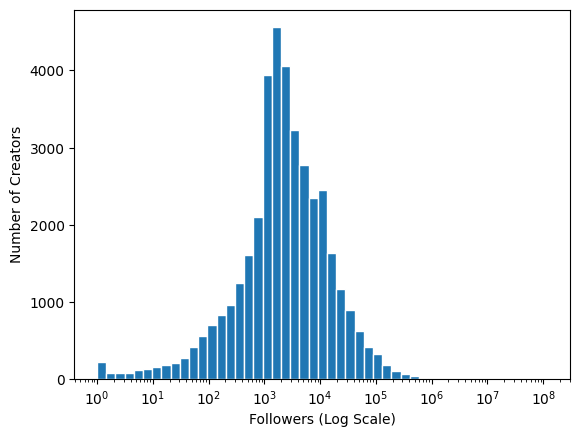

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create log-spaced bins so the bars are even on a log scale
bins = np.logspace(np.log10(df['follower'].min() + 1),
                   np.log10(df['follower'].max()), 50)

plt.hist(df['follower'], bins=bins, edgecolor='white')
plt.xscale('log')  # This is the key line
plt.xlabel('Followers (Log Scale)')
plt.ylabel('Number of Creators')
plt.show()

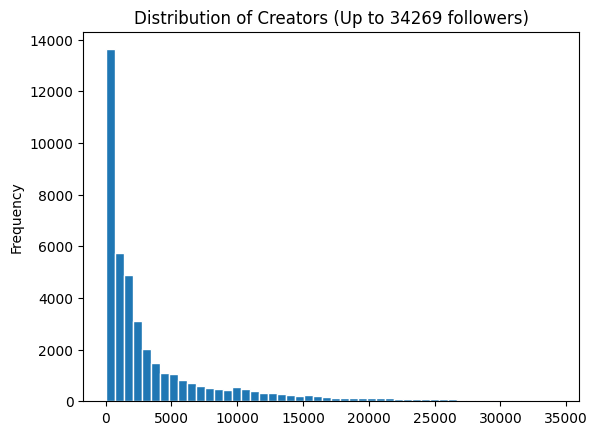

In [ ]:
# Only plot creators up to the 95th percentile
upper_limit = df['follower'].quantile(0.95)
df[df['follower'] <= upper_limit]['follower'].plot.hist(
    bins=50, edgecolor='white')

plt.title(f'Distribution of Creators (Up to {int(upper_limit)} followers)')
plt.show()